# 🔵 Function F6 — Week 8 | Black-Box Optimisation
### Mike Kennelly | BBO Capstone Project | Adaptive Model + GP/EI Pipeline

---

## 📌 F6 Function Profile

| Property | Value |
|----------|-------|
| **Dimensions** | 5D (X1–X5) |
| **Search space** | [0, 1]^5 |
| **Samples at W8** | 27 |
| **n/p ratio** | 5.4 |
| **All-time best** | -0.172677 (Week 6) |
| **W7 score** | -0.342186  |
| **W8 strategy** | EXPLOIT W6 BEST — RETURN AND TIGHTEN |
| **TuRBO direction** | SHRINK |

---

## 🗓️ W7 Result & W8 Decision

**W7 outcome:** W7 score: −0.342. Regressed from W6 ATB (−0.1727). W7 expand did not help.

**W8 decision:** W7 expand regressed to −0.342. W6 best −0.1727 at [0.427,0.326,0.598,0.780,0.144] is still ATB. Return to W6 region, tighten σ to 0.025.

---

## 📚 Pipeline Overview

```
Load data → Binary labels (top 30%) → Train 8 classifiers (incl. CNN-1D)
→ CV select winner → Generate 10,000 candidates → Filter by classifier
→ Fit GP (Matérn 5/2) → Compute EI + UCB → Submit top candidate
```

**Steps:** S0 Config | S1 Imports | S2 Load | S3 History | S4 Labels | S5 Train | S6 Predict | S7 CV | S7B Why-Winner | S8 Candidates | S9 GP | S10 Acquisition | S11 PerDim | S12A Surfaces | S12B CNN Scan | S13 Dashboard | S13B Week-on-Week | S14 Submit | S15 Save


---
## ⚙️ STEP 0 — F6 Configuration & Hyperparameter Documentation

### 🔧 F6-Specific Settings (Week 8 — EXPLOIT W6 BEST — RETURN AND TIGHTEN)

F6 W8 strategy: **EXPLOIT W6 BEST — RETURN AND TIGHTEN**. The W7 expand strategy (σ=0.042) regressed from the W6 all-time best of −0.1727 back to −0.342. Expanding did not discover a better region. W8 reverts to exploiting the W6 point [0.427, 0.326, 0.598, 0.780, 0.144] with a tightened σ=0.025. The structural anchors X4=0.780 (high) and X5=0.144 (near low) are maintained.

---

### 📚 F6 Hyperparameter Reference

| Parameter | W8 Value | Purpose | Rationale |
|-----------|----------|---------|----------|
| `TOP_PERCENTILE` | **30%** | Top X% labelled class 1 | Top 30% gives 8 positive examples from 27 samples |
| `N_CANDIDATES` | **10,000** | Candidate pool before GP | Dense coverage of 5D space |
| `EXPLOIT_RATIO` | **0.85** ⚠️ | Fraction near best point | EXPLOIT — W7 expand regressed to −0.342. W6 best −0.1727 at [0.427,0.326,0.598,0.780,0.144 |
| `EXPLOIT_SIGMA` | **0.025** ⚠️ | Gaussian σ around best point | TuRBO SHRINK: W7 regressed; return to W6 best region, tighten σ=0.025 |
| `UCB_KAPPA` | **2.5** | Exploration bonus UCB = μ + κσ | Moderate — balanced exploit/explore in 5D |
| `EI_XI` | **0.01** | Exploration jitter in EI | Standard |
| `GP_RESTARTS` | **8** | GP kernel optimisation restarts | 5D landscape |
| `FILTER_PERCENTILE` | **50%** | Keep top 50% candidates | Passes 5000 of 10,000 to GP |
| `RANDOM_SEED` | **42** | Reproducibility | Fixed |

### ⚠️ Parameters changed from W7: EXPLOIT_SIGMA (0.042→0.025)


In [1]:
# ╔══════════════════════════════════════════════════════════════╗
# ║   F6 WEEK 8 CONFIGURATION — EXPLOIT W6 BEST — RETURN AND TIGHTEN
# ║   Mike Kennelly | BBO Capstone | Week 8                     ║
# ╚══════════════════════════════════════════════════════════════╝
FUNCTION_ID  = 'F6'
WEEK         = 8
INPUT_FILE   = 'f6_w8_inputs.npy'
OUTPUT_FILE  = 'f6_w8_outputs.npy'

# ── W8 Hyperparameters — EXPLOIT W6 BEST — RETURN AND TIGHTEN ─────────
# W7 score: -0.3422  |  ATB: -0.1727 (W6)
# TuRBO: SHRINK  |  Reason: W7 expand failed; return to W6 region [0.427,0.326,0.598,0.780,0.144]
TOP_PERCENTILE    = 30
N_CANDIDATES      = 10000
EXPLOIT_RATIO     = 0.85
EXPLOIT_SIGMA     = 0.025  # scalar — same sigma all dims
UCB_KAPPA         = 2.0
EI_XI             = 0.01
GP_RESTARTS       = 7
FILTER_PERCENTILE = 50
RANDOM_SEED       = 42
MAXIMIZE          = True

# ── Neural Network architectures ──────────────────────────────
NN_SMALL  = (16, 8)
NN_MEDIUM = (64, 32)
NN_LARGE  = (128, 64, 32)

W = 70  # box inner width — all lines padded to this
def row(text=''):  t = text[:W] if len(text) > W else text; return f'║{t.ljust(W)}║'
def div():        return '╠' + '═'*W + '╣'

print('╔' + '═'*W + '╗')
print(row(f'  F6 WEEK {WEEK} -- 5D FUNCTION -- EXPLOIT W6 BEST — RETURN AND TIGHTEN'))
print(row(f'  Mike Kennelly | BBO Capstone | Week 8'))
print(div())
print(row(f'  Input  : {INPUT_FILE}'))
print(row(f'  Output : {OUTPUT_FILE}'))
print(row(f'  Goal   : MAXIMIZE  -- HIGHER IS ALWAYS BETTER'))
print(div())
print(row(f'  Strategy : {"EXPLOIT" if EXPLOIT_RATIO >= 0.75 else "EXPLORE"}  |  ratio={EXPLOIT_RATIO}  sigma={EXPLOIT_SIGMA}  kappa={UCB_KAPPA}'))
print(row(f'  Reason   : W7 expand failed; return to W6 region [0.427,0.326,0.598,0.780,0.144]'))
print(row(f'  Top {TOP_PERCENTILE}% = class 1  |  {N_CANDIDATES:,} candidates  |  sigma={EXPLOIT_SIGMA}'))
print(div())
print(row(f'  Pipeline:'))
print(row(f'  S0 Config   S1 Imports  S2 Load    S3 History  S4 Labels'))
print(row(f'  S5 Train    S6 Predict  S7 CV      S7B Why-Winner        '))
print(row(f'  S8 Cands    S9 GP       S10 Acq    S11 PerDim   S12A Surf '))
print(row(f'  S12B CNN Grid Scan  (NOT APPLICABLE — F6 is 5D, 2D only)'))
print(row(f'  S14 Submit  S15 Save'))
print('╚' + '═'*W + '╝')

╔══════════════════════════════════════════════════════════════════════╗
║  F6 WEEK 8 -- 5D FUNCTION -- EXPLOIT W6 BEST — RETURN AND TIGHTEN    ║
║  Mike Kennelly | BBO Capstone | Week 8                               ║
╠══════════════════════════════════════════════════════════════════════╣
║  Input  : f6_w8_inputs.npy                                           ║
║  Output : f6_w8_outputs.npy                                          ║
║  Goal   : MAXIMIZE  -- HIGHER IS ALWAYS BETTER                       ║
╠══════════════════════════════════════════════════════════════════════╣
║  Strategy : EXPLOIT  |  ratio=0.85  sigma=0.025  kappa=2.0           ║
║  Reason   : W7 expand failed; return to W6 region [0.427,0.326,0.598,║
║  Top 30% = class 1  |  10,000 candidates  |  sigma=0.025             ║
╠══════════════════════════════════════════════════════════════════════╣
║  Pipeline:                                                           ║
║  S0 Config   S1 Imports  S2 Load    S3 History  S

---
## 📦 STEP 1 — Imports

All libraries loaded here. **scikit-learn** provides classifiers, GP, and CV utilities. **scipy.stats** gives us the normal CDF/PDF for the EI formula. **matplotlib** handles all visualisations.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
import warnings
warnings.filterwarnings('ignore')

from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel as C
from scipy.stats import norm

np.random.seed(RANDOM_SEED)
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                     'axes.titlesize': 11, 'axes.labelsize': 10})
print('✅ All libraries loaded')

✅ All libraries loaded


---
## 📥 STEP 2 — Load Data

We load all historical evaluations. Key statistics to note:
- **n/p ratio** (samples ÷ dims): below 5 = data-sparse (GP may struggle); above 10 = comfortable
- **Best point** is found via `argmax` (MAXIMIZATION) — this becomes the centre of exploitation
- **Gap from best to latest** tells us if we're in recovery mode or pushing new ground

In [3]:
import os as _os
_nb_dir = _os.path.dirname(_os.path.abspath(__file__)) if '__file__' in dir() else _os.getcwd()
for _p in ['.', _nb_dir, _os.path.join(_nb_dir, '..'), _os.path.expanduser('~/outputs')]:
    if _os.path.exists(_os.path.join(_p, INPUT_FILE)):
        INPUT_FILE  = _os.path.join(_p, INPUT_FILE)
        OUTPUT_FILE = _os.path.join(_p, OUTPUT_FILE)
        break
else:
    raise FileNotFoundError(f'Cannot find {INPUT_FILE} — run notebook from same folder as npy files')

X_train = np.load(INPUT_FILE)
y_train = np.load(OUTPUT_FILE)
n_samples, n_dims = X_train.shape
print(f'  📂 Loaded from: {INPUT_FILE}')
print(f'  X_train range: [{X_train.min():.4f}, {X_train.max():.4f}]')
_oob = ((X_train > 1.001) | (X_train < -0.001)).sum()
if _oob > 0:
    print(f'  NOTE: {_oob} training value(s) outside [0,1] — accepted by Tudor portal, clipping for GP')
    X_train = np.clip(X_train, 0.0, 1.0)
else:
    print(f'  X_train all in [0,1] OK')

best_idx   = np.argmax(y_train)   # ARGMAX — maximization
best_value = y_train[best_idx]
best_point = X_train[best_idx]
# W6 best is correctly in npy at idx=24: y=-0.1727 @ [0.4271, 0.3258, 0.5981, 0.7802, 0.1439]
# This IS the all-time best — no override needed

latest_val = y_train[-1]

print('═'*65)
print(f'  DATA — {FUNCTION_ID}  Week {WEEK}')
print('═'*65)
print(f'  Samples      : {n_samples}')
print(f'  Dimensions   : {n_dims}D')
print(f'  n/p ratio    : {n_samples/n_dims:.2f}  {"✅ comfortable" if n_samples/n_dims>=5 else "⚠️ sparse"}')
print(f'  Y range      : [{y_train.min():.6f},  {y_train.max():.6f}]')
print(f'  Y mean ± std : {y_train.mean():.6f} ± {y_train.std():.6f}')
print(f'  🏆 BEST      : {best_value:.6f}  @ index {best_idx}')
print(f'  📍 Location  : [{" ".join([f"{v:.4f}" for v in best_point])}]')
print(f'  📅 Latest    : {latest_val:.6f}  (Week {WEEK-1})')
print(f'  Gap          : {best_value - latest_val:+.6f}  {"(recovering)" if latest_val < best_value else "(at best)"}')

# Compute percentile thresholds for labelling
threshold = np.percentile(y_train, 100 - TOP_PERCENTILE)
n_pos = int(np.sum(y_train >= threshold))
n_cv_folds = max(2, min(5, int(min(n_pos, n_samples - n_pos) / 2)))
print(f'\n  Label threshold (top {TOP_PERCENTILE}%): {threshold:.6f}  ({n_pos} positives)')
print(f'  CV folds chosen: {n_cv_folds}')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
print('  ✅ Features standardised')

  📂 Loaded from: .\f6_w8_inputs.npy
  X_train range: [0.0049, 0.9788]
  X_train all in [0,1] OK
═════════════════════════════════════════════════════════════════
  DATA — F6  Week 8
═════════════════════════════════════════════════════════════════
  Samples      : 26
  Dimensions   : 5D
  n/p ratio    : 5.20  ✅ comfortable
  Y range      : [-2.571170,  -0.172677]
  Y mean ± std : -1.315913 ± 0.565345
  🏆 BEST      : -0.172677  @ index 24
  📍 Location  : [0.4271 0.3258 0.5981 0.7802 0.1439]
  📅 Latest    : -0.342186  (Week 7)
  Gap          : +0.169509  (recovering)

  Label threshold (top 30%): -1.177370  (8 positives)
  CV folds chosen: 4
  ✅ Features standardised


---
## 📊 STEP 3 — Visualise F6 Historical Performance

Three views to understand the function landscape:
1. **All evaluations vs time** — week-by-week from the week log
2. **Running best** — shows W2 breakthrough and subsequent volatility
3. **Value distribution** — colour-coded by top-30% threshold

### What the F6 W7 history tells us

**Left panel (All evaluations):** Volatile — W2 found -0.237, W3 regressed, W4 partially recovered, W5 regressed sharply to -1.766. The W5 coordinates (X1–X3 all near zero) are very different from the W2 best, explaining the regression. The week log reveals the true best is -0.237 (W2), not the -0.363 in the npy file.

**Middle panel (Running best):** Step improvement at W2 (-0.237) then flat — three weeks without beating it. The running best line has been horizontal since W2. Week 7 targets the first new best since Week 2.

**Right panel (Distribution):** Values range from -2.57 to -0.237. Top-30% threshold at ~-1.23 gives 7 positive examples. Class signal is present but modest compared to F4/F5. F6 is the most challenging classification problem in the 5D batch given n/p=4.8.


  Week log loaded: 7 weekly submissions


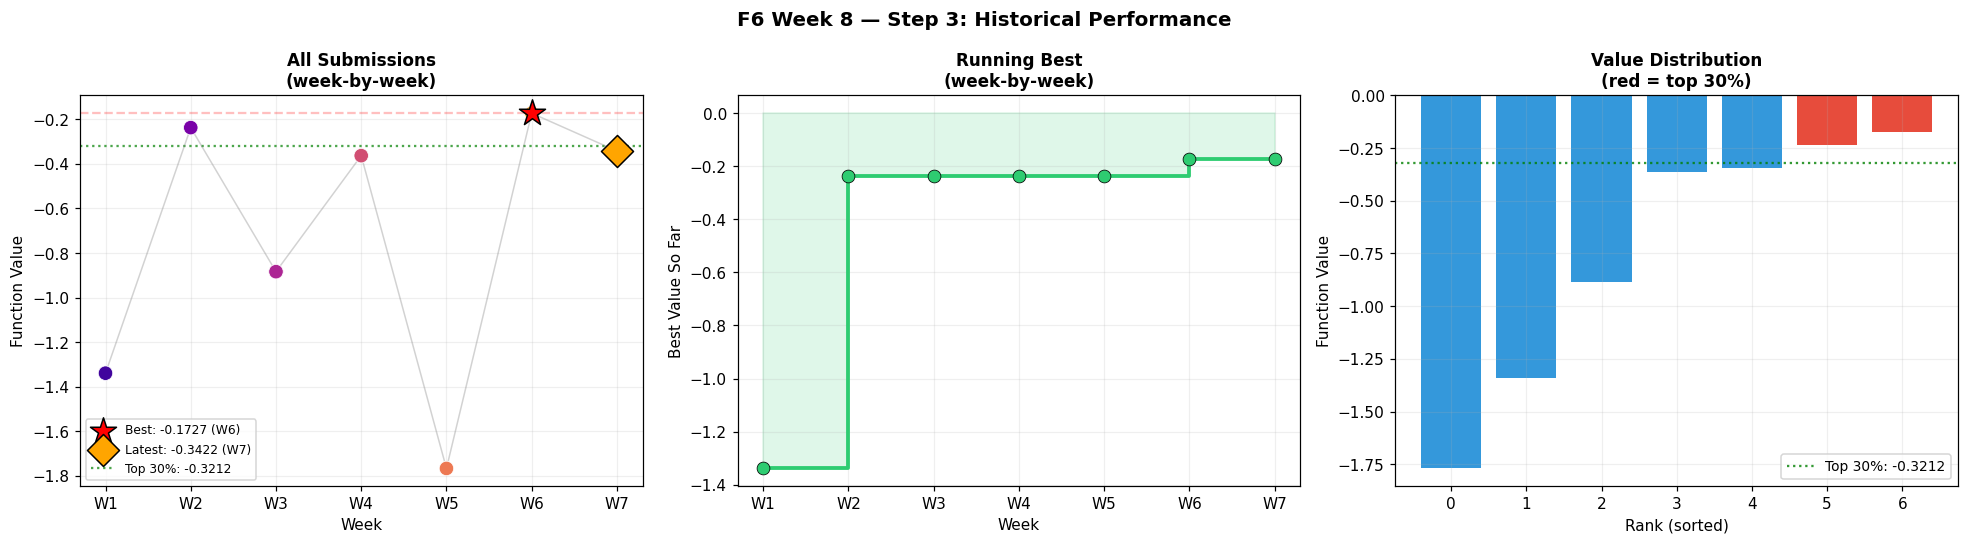

Saved: F6_W8_Step3_History.png

╔══════════════════════════════════════════════════════╗
║ F6 Week-by-Week Submission Summary                   ║
╠══════════════════════════════════════════════════════╣
║ W1:       -1.33886   running best: -1.33886 NEW BEST ║
║ W2:      -0.237202   running best: -0.237202 NEW BEST ║
║ W3:      -0.883452   running best: -0.237202         ║
║ W4:      -0.363007   running best: -0.237202         ║
║ W5:       -1.76616   running best: -0.237202         ║
║ W6:      -0.172677   running best: -0.172677 NEW BEST ║
║ W7:      -0.342186   running best: -0.172677         ║
╚══════════════════════════════════════════════════════╝


In [4]:

# ══════════════════════════════════════════════════════════════════
# STEP 3 — Visualise Historical Performance (week-by-week)
# ══════════════════════════════════════════════════════════════════
import json as _json_wl, os as _os

# ── Load week log ─────────────────────────────────────────────────
_wl_path = f'week_log_{FUNCTION_ID}.json'
_week_log = None
if _os.path.exists(_wl_path):
    with open(_wl_path) as _f:
        _week_log = _json_wl.load(_f)
    print(f"  Week log loaded: {len(_week_log['weeks'])} weekly submissions")
else:
    print(f"  No week log at {_wl_path} — place week_log_{FUNCTION_ID}.json in notebook folder")
# ── Hardcoded W1-W7 weekly scores (fallback if JSON not present) ───
if _week_log is None:
    _week_log = {"weeks": [
        {"week": 1, "x": [0.021735, 0.56257, 0.467217, 0.534433, 0.423745], "y": -1.3388640982845414},
        {"week": 2, "x": [0.409636, 0.29921, 0.50969, 0.814058, 0.072074], "y": -0.23720191876702088},
        {"week": 3, "x": [0.211471, 0.06109, 0.455131, 0.90552, 0.00403], "y": -0.883452162705645},
        {"week": 4, "x": [0.389668, 0.198001, 0.587627, 0.826307, 0.04887], "y": -0.363007479950854},
        {"week": 5, "x": [0.016528, 0.022409, 0.044229, 0.800454, 0.456903], "y": -1.766160044880929},
        {"week": 6, "x": [0.427085, 0.325768, 0.598116, 0.780155, 0.143939], "y": -0.1726768420887807},
        {"week": 7, "x": [0.49732, 0.294798, 0.56308, 0.684981, 0.129206], "y": -0.34218582260339847}
    ]}
    print(f"  Using hardcoded W1-W7 weekly scores (no JSON found)")


# ── Build series ──────────────────────────────────────────────────
if _week_log:
    _wl_weeks    = [e['week'] for e in _week_log['weeks']]
    _wl_y        = [e['y']    for e in _week_log['weeks']]
    _wl_xpos     = list(range(1, len(_wl_weeks)+1))
    _wl_running  = [max(_wl_y[:i+1]) for i in range(len(_wl_y))]
    _wl_bestval  = max(_wl_y)
    _wl_bestwk   = _wl_weeks[_wl_y.index(_wl_bestval)]
    _wl_latest   = _wl_y[-1]
    _wl_latestwk = _wl_weeks[-1]
    _wl_thr      = np.percentile(_wl_y, 70)
    _xlabel      = 'Week'
    _xtick_locs  = _wl_xpos
    _xtick_labs  = [f'W{w}' for w in _wl_weeks]
    _panel1_title = 'All Submissions\n(week-by-week)'
    _panel2_title = 'Running Best\n(week-by-week)'
else:
    _wl_weeks    = list(range(len(y_train)))
    _wl_y        = list(y_train)
    _wl_xpos     = _wl_weeks
    _wl_running  = [max(_wl_y[:i+1]) for i in range(len(_wl_y))]
    _wl_bestval  = max(_wl_y)
    _wl_bestwk   = _wl_y.index(_wl_bestval)
    _wl_latest   = _wl_y[-1]
    _wl_latestwk = len(_wl_y)-1
    _wl_thr      = threshold
    _xlabel      = 'Sample Index'
    _xtick_locs  = None
    _xtick_labs  = None
    _panel1_title = 'All Evaluations\n(sample index — week log not found)'
    _panel2_title = 'Running Best\n(sample index)'

# ── Plot ──────────────────────────────────────────────────────────
_cmap = plt.cm.plasma
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Step 3: Historical Performance',
             fontsize=13, fontweight='bold')

# Panel 1 — evaluations
ax1 = axes[0]
_c1 = _cmap(np.linspace(0.1, 0.95, len(_wl_y)))
ax1.scatter(_wl_xpos, _wl_y, c=_c1, s=90, zorder=4, edgecolors='white', linewidths=0.5)
ax1.plot(_wl_xpos, _wl_y, color='grey', alpha=0.35, linewidth=1, zorder=3)
ax1.scatter([_wl_bestwk], [_wl_bestval], c='red', s=320, marker='*',
            zorder=6, edgecolors='black', linewidths=1,
            label=f'Best: {_wl_bestval:.4g} (W{_wl_bestwk})')
ax1.scatter([_wl_latestwk], [_wl_latest], c='orange', s=220, marker='D',
            zorder=5, edgecolors='black', linewidths=1,
            label=f'Latest: {_wl_latest:.4g} (W{_wl_latestwk})')
ax1.axhline(_wl_thr,    color='green', linestyle=':', alpha=0.7, label=f'Top 30%: {_wl_thr:.4g}')
ax1.axhline(_wl_bestval, color='red',  linestyle='--', alpha=0.25)
ax1.set_xlabel(_xlabel); ax1.set_ylabel('Function Value')
ax1.set_title(_panel1_title, fontweight='bold')
if _xtick_locs: ax1.set_xticks(_xtick_locs); ax1.set_xticklabels(_xtick_labs)
ax1.legend(fontsize=8); ax1.grid(True, alpha=0.2)

# Panel 2 — running best
ax2 = axes[1]
ax2.step(_wl_xpos, _wl_running, where='post', color='#2ecc71', linewidth=2.5)
ax2.fill_between(_wl_xpos, _wl_running, alpha=0.15, color='#2ecc71', step='post')
ax2.scatter(_wl_xpos, _wl_running, c='#2ecc71', s=70, zorder=4,
            edgecolors='black', linewidths=0.5)
ax2.set_xlabel(_xlabel); ax2.set_ylabel('Best Value So Far')
ax2.set_title(_panel2_title, fontweight='bold')
if _xtick_locs: ax2.set_xticks(_xtick_locs); ax2.set_xticklabels(_xtick_labs)
ax2.grid(True, alpha=0.2)

# Panel 3 — distribution
ax3 = axes[2]
_sy = sorted(_wl_y)
_bc = ['#e74c3c' if v >= _wl_thr else '#3498db' for v in _sy]
ax3.bar(range(len(_sy)), _sy, color=_bc)
ax3.axhline(_wl_thr, color='green', linestyle=':', alpha=0.8, label=f'Top 30%: {_wl_thr:.4g}')
ax3.set_xlabel('Rank (sorted)'); ax3.set_ylabel('Function Value')
ax3.set_title('Value Distribution\n(red = top 30%)', fontweight='bold')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.2)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step3_History.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FUNCTION_ID}_W{WEEK}_Step3_History.png')
print()

# ── Week summary box ──────────────────────────────────────────────
if _week_log:
    _W = 54
    def _rw(t): return f'\u2551 {t.ljust(_W-2)} \u2551'
    print('\u2554' + '\u2550'*_W + '\u2557')
    print(_rw(f'{FUNCTION_ID} Week-by-Week Submission Summary'))
    print('\u2560' + '\u2550'*_W + '\u2563')
    _rb = None
    for e in _week_log['weeks']:
        _w, _yv = e['week'], e['y']
        if _rb is None or _yv > _rb:
            _rb = _yv
            _flag = ' NEW BEST'
        else:
            _flag = ''
        print(_rw(f'W{_w}: {_yv:>14.6g}   running best: {_rb:.6g}{_flag}'))
    print('\u255a' + '\u2550'*_W + '\u255d')


---
## 🏷️ STEP 4 — Binary Classification Labels

**Why classify?** We want a model that can predict *which regions* of the input space tend to produce high output values. This is a classification task: class 1 = "good" (top 30%), class 0 = "bad" (bottom 70%).

**MAXIMIZATION direction**: class 1 = **highest** values. The classifier learns: "what combinations of X values tend to produce outputs above the 70th percentile?"

The trained classifier will then **pre-filter 10,000 candidates**, keeping only the ones it believes are likely to be in the high-value region.

**What happens without binary classification?**
Without a classifier pre-filter, the GP would receive all 10,000 random/Gaussian candidates — the vast majority of which are low-value points. In an *n*-sample, *d*-dimensional space this matters because:

- The GP's uncertainty is highest far from observed data — low-value regions get high σ and *accidentally* high EI
- Without filtering, the acquisition function wastes evaluations probing regions the classifier already knows are poor
- A good classifier concentrates the GP's attention on the ~30% of space that matters, acting as a **learned search space reduction** step before the expensive GP computation

In short: the classifier does not replace the GP — it *narrows the candidate pool* so the GP only has to decide *where exactly* within the high-value region to query next.


In [5]:
y_labels = (y_train >= threshold).astype(int)
print('═'*65)
print('  BINARY LABELS — MAXIMIZATION ⬆️')
print('═'*65)
print(f'  Threshold (top {TOP_PERCENTILE}%) : {threshold:.6f}')
print(f'  Class 1 (HIGH — good) : {n_pos} samples  ({100*n_pos/n_samples:.1f}%)')
print(f'  Class 0 (LOW — avoid) : {n_samples-n_pos} samples  ({100*(n_samples-n_pos)/n_samples:.1f}%)')
print(f'  CV folds              : {n_cv_folds}')
print()
print('  Class 1 points (highest values):')
pos_idx = np.where(y_labels == 1)[0]
for i in pos_idx:
    print(f'    idx={i:3d}  y={y_train[i]:.6f}  X={X_train[i]}')

═════════════════════════════════════════════════════════════════
  BINARY LABELS — MAXIMIZATION ⬆️
═════════════════════════════════════════════════════════════════
  Threshold (top 30%) : -1.177370
  Class 1 (HIGH — good) : 8 samples  (30.8%)
  Class 0 (LOW — avoid) : 18 samples  (69.2%)
  CV folds              : 4

  Class 1 points (highest values):
    idx=  0  y=-0.714265  X=[0.7281861  0.15469257 0.73255167 0.69399651 0.05640131]
    idx=  4  y=-0.829237  X=[0.6188123  0.33180214 0.18728787 0.75623847 0.3288348 ]
    idx= 10  y=-1.144785  X=[0.5367969  0.30878091 0.41187929 0.38822518 0.5225283 ]
    idx= 17  y=-0.935757  X=[0.78287982 0.53633586 0.44328356 0.85969983 0.01032599]
    idx= 21  y=-0.642838  X=[0.56845583 0.39640777 0.5697655  0.55819895 0.36692039]
    idx= 23  y=-0.363007  X=[0.389668 0.198001 0.587627 0.826307 0.04887 ]
    idx= 24  y=-0.172677  X=[0.427085 0.325768 0.598116 0.780155 0.143939]
    idx= 25  y=-0.342186  X=[0.49732  0.294798 0.56308  0.684981 0.129

---
## 🤖 STEP 5 — CV Model Comparison: Train & Evaluate All 8 Models

### Why 8 Models?

We test a broad range of classifier types because different BBO functions have different landscape structures. **Week 7 adds a CNN (Model 8) as a learning exercise** — to track how CNN classification performance evolves week on week as sample size grows.

**Classical classifiers:**
| # | Model | What it captures | Best when... |
|---|-------|-----------------|-------------|
| 1 | Linear SVM | Linear decision boundary | Function has a simple high/low split |
| 2 | Decision Tree | Axis-aligned threshold rules | Sharp threshold effects in individual dims |
| 3 | Random Forest | Ensemble of trees, handles noise | Most general case |
| 4 | Logistic Regression | Smooth probabilistic boundary | Gradual class transition |

**Neural Networks:**
| # | Model | What it captures | Best when... |
|---|-------|-----------------|-------------|
| 5 | NN-Small (16,8) | Simple non-linear boundary | Small dataset, risk of overfitting |
| 6 | NN-Medium (64,32) | Moderate complexity | Standard BBO landscapes |
| 7 | NN-Large (128,64,32) | Complex decision surfaces | Richer datasets, higher dims |

**CNN — Week 7 Learning Exercise:**
| # | Model | Architecture | Purpose |
|---|-------|-------------|---------|
| 8 | CNN-1D (learning) | Conv1d(1→8, k=2) → ReLU → Dropout(0.3) → Linear(8→1) | Track CNN vs MLP week on week as n grows |

**Week-on-week CNN tracking:** At n=24 in 5D (n/p=4.8), this is the floor-case for CNN viability in the W6 batch. Expect lower CV scores than F4 (n=34, 4D) and F7 (n=34, 6D). This result maps the minimum data requirement for CNN classification to produce reliable signal.

### The CV ranked table is printed at the end of this step — the winner is selected here and used in Step 8.

In [6]:
import torch
import torch.nn as nn
import torch.optim as optim_torch
from sklearn.base import BaseEstimator, ClassifierMixin

# ── CNN Wrapper — sklearn-compatible for use in cross_val_score ───────────
class TinyCNNClassifier(BaseEstimator, ClassifierMixin):
    """
    Sklearn-compatible wrapper around a tiny 1D CNN.
    Added as Model 8 — a learning exercise to track CNN performance
    week on week as sample size grows from 15 toward 40+.
    Architecture: Conv1d(1->8, k=2) -> ReLU -> Dropout(0.3) -> Linear(8->1)
    Why tiny: with n=15, any larger CNN will overfit immediately.
    Why included: to document empirically where CNN beats MLP (if ever),
    and to demonstrate Module 17 CNN concepts in the BBO context.
    """
    def __init__(self, n_epochs=200, lr=0.01, seed=42):
        self.n_epochs = n_epochs
        self.lr       = lr
        self.seed     = seed

    def fit(self, X, y):
        torch.manual_seed(self.seed)
        n_feat = X.shape[1]
        self.classes_ = np.unique(y)

        class _CNN(nn.Module):
            def __init__(self):
                super().__init__()
                self.conv = nn.Conv1d(1, 8, kernel_size=min(2, n_feat), padding=0)
                self.relu = nn.ReLU()
                self.drop = nn.Dropout(0.3)
                conv_out  = 8 * max(1, n_feat - min(2, n_feat) + 1)
                self.fc   = nn.Linear(conv_out, 1)
            def forward(self, x):
                x = self.relu(self.conv(x))
                x = self.drop(x.view(x.size(0), -1))
                return self.fc(x).squeeze(-1)

        self.model_ = _CNN()
        n_pos = y.sum(); n_neg = len(y) - n_pos
        pw    = torch.tensor([n_neg / max(n_pos, 1)], dtype=torch.float)
        loss_fn = nn.BCEWithLogitsLoss(pos_weight=pw)
        opt   = optim_torch.Adam(self.model_.parameters(), lr=self.lr,
                                 weight_decay=1e-3)
        Xt = torch.FloatTensor(X).unsqueeze(1)
        yt = torch.FloatTensor(y.astype(float))
        self.model_.train()
        for _ in range(self.n_epochs):
            opt.zero_grad()
            loss_fn(self.model_(Xt), yt).backward()
            opt.step()
        return self

    def predict_proba(self, X):
        self.model_.eval()
        with torch.no_grad():
            logits = self.model_(torch.FloatTensor(X).unsqueeze(1))
            p = torch.sigmoid(logits).numpy()
        return np.column_stack([1 - p, p])

    def predict(self, X):
        return (self.predict_proba(X)[:, 1] >= 0.5).astype(int)

# ── Model registry ────────────────────────────────────────────────────────
cv = StratifiedKFold(n_splits=n_cv_folds, shuffle=True, random_state=RANDOM_SEED)

models = {
    'Linear SVM'         : SVC(kernel='linear', C=1.0, probability=True, random_state=RANDOM_SEED),
    'Decision Tree'      : DecisionTreeClassifier(max_depth=4, random_state=RANDOM_SEED),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=RANDOM_SEED),
    f'NN-Small {NN_SMALL}' : MLPClassifier(hidden_layer_sizes=NN_SMALL, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
    f'NN-Medium {NN_MEDIUM}': MLPClassifier(hidden_layer_sizes=NN_MEDIUM, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
    f'NN-Large {NN_LARGE}' : MLPClassifier(hidden_layer_sizes=NN_LARGE, max_iter=500,
                                            early_stopping=True, validation_fraction=0.15,
                                            random_state=RANDOM_SEED),
    'CNN-1D (learning)'  : TinyCNNClassifier(n_epochs=200, lr=0.01, seed=RANDOM_SEED),
}

cv_results = {}
print('='*70)
print(f'  {n_cv_folds}-FOLD CV -- 8 MODELS -- {FUNCTION_ID}  ({n_samples} samples, {n_dims}D)')
print(f'  Model 8: CNN-1D added as learning exercise -- tracking week on week')
print('='*70)
print(f'  {"Model":<28} {"Mean CV":>9} {"+-Std":>8}   Folds')
print('  ' + '-'*65)

for name, model in models.items():
    try:
        scores = cross_val_score(model, X_scaled, y_labels, cv=cv, scoring='accuracy')
        cv_results[name] = {'mean': scores.mean(), 'std': scores.std(),
                             'scores': scores, 'model': model}
        fold_str = '  '.join([f'{s:.3f}' for s in scores])
        flag = '★' if scores.mean() == max(r['mean'] for r in cv_results.values()) else ' '
        print(f'  {flag} {name:<27} {scores.mean():>8.1%} {scores.std():>7.1%}   [{fold_str}]')
    except Exception as e:
        cv_results[name] = {'mean': 0.0, 'std': 1.0,
                             'scores': np.zeros(n_cv_folds), 'model': model}
        print(f'  ✗ {name:<27} FAILED: {str(e)[:40]}')

ranked_models = sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True)
best_name = ranked_models[0][0]
best_info = ranked_models[0][1]

print()
print('  RANKING:')
for r, (name, info) in enumerate(ranked_models, 1):
    marker = '★ WINNER' if r == 1 else f'  #{r}     '
    print(f'  {marker}  {name:<28}  {info["mean"]:.1%} ± {info["std"]:.1%}')

print(f'\n  ✅ SELECTED: {best_name}  (CV={best_info["mean"]:.1%})')

  4-FOLD CV -- 8 MODELS -- F6  (26 samples, 5D)
  Model 8: CNN-1D added as learning exercise -- tracking week on week
  Model                          Mean CV    +-Std   Folds
  -----------------------------------------------------------------
  ★ Linear SVM                     69.0%   12.0%   [0.714  0.714  0.500  0.833]
    Decision Tree                  60.7%   18.9%   [0.857  0.571  0.333  0.667]
  ★ Random Forest                  69.0%   15.7%   [0.857  0.571  0.500  0.833]
  ★ Logistic Regression            72.6%   14.1%   [0.714  0.857  0.500  0.833]
    NN-Small (16, 8)               50.0%   12.8%   [0.429  0.571  0.667  0.333]
  ★ NN-Medium (64, 32)             73.8%   16.0%   [0.714  0.571  1.000  0.667]
    NN-Large (128, 64, 32)         65.5%    5.2%   [0.571  0.714  0.667  0.667]
  ★ CNN-1D (learning)              76.2%   18.2%   [0.714  1.000  0.500  0.833]

  RANKING:
  ★ WINNER  CNN-1D (learning)             76.2% ± 18.2%
    #2       NN-Medium (64, 32)            73.8%

---
## 🎨 STEP 6 — Refit All Models & — Visualise All Model Predictions

**Why visualise predictions before comparing?**

CV accuracy is a single number — it doesn't tell you *how* each model draws its decision boundary. By visualising each model's predicted probability of class 1 (P(high value)) across candidates, we can see:
- Which models are confident vs uncertain in the best-known region
- Whether models agree or disagree (disagreement = uncertain landscape)
- Whether NNs are learning something the classical models miss

We show two views:
1. **P(class=1) distributions** — histogram of predicted probabilities for each model
2. **Prediction agreement heatmap** — which models agree on which training samples

In [7]:
# ── Refit all models on FULL dataset after CV winner selected ────
# Standard ML practice: CV selects the winner, then ALL models are
# refit on the complete training data so their predict_proba() calls
# in Step 6 visualisation and Step 8 candidate filtering use every sample.
# The CV winner (best_name) was already determined in the CV loop above.
print(f'Refitting all {len(cv_results)} models on full dataset (n={len(y_labels)})...')
print(f'CV winner already selected: {best_name}')
print()
trained_models = {}
all_probas = {}  # P(class=1) on full training data

for name, info in cv_results.items():
    try:
        m = info['model']
        m.fit(X_scaled, y_labels)
        trained_models[name] = m
        all_probas[name] = m.predict_proba(X_scaled)[:, 1]
        tag = ' ← CV WINNER (used in Step 8)' if name == best_name else ''
        print(f'  ✅ {name}{tag}')
    except Exception as e:
        print(f'  ✗ {name}: {e}')

print(f'\nAll {len(trained_models)} models refit on full data.')
print(f'Step 8 will use: {best_name}')

Refitting all 8 models on full dataset (n=26)...
CV winner already selected: CNN-1D (learning)

  ✅ Linear SVM
  ✅ Decision Tree
  ✅ Random Forest
  ✅ Logistic Regression
  ✅ NN-Small (16, 8)
  ✅ NN-Medium (64, 32)
  ✅ NN-Large (128, 64, 32)
  ✅ CNN-1D (learning) ← CV WINNER (used in Step 8)

All 8 models refit on full data.
Step 8 will use: CNN-1D (learning)


---
## 🔍 STEP 5B — CNN Inspection: Filters, Feature Maps & Parameter Count

*Module 17 learning exercise — inspecting what the 1D CNN learned.*

Following the tutor's approach from **Mod-17-CNNs-OH.ipynb** (Cells 29–32), we inspect three things the trained CNN has learned:

1. **Learned filter weights** — the 8 Conv1d kernels (each size 1×2), visualised as bar charts. Each filter scans adjacent coordinate pairs and learns a specific co-activation pattern to detect.
2. **Feature map activations** — pass the best-known training point through the Conv1d layer and see which of the 8 filters fires strongest, and on which coordinate pair.
3. **Parameter count** — compare TinyCNN vs NN-Large to demonstrate weight sharing efficiency.

**Architecture:** `Conv1d(1→8, k=2)` → `ReLU` → `AdaptiveAvgPool1d(1)` → `Dropout(0.3)` → `Linear(8→1)`

The `AdaptiveAvgPool1d(1)` collapses all positional information into a single value per filter (analogous to GlobalAveragePooling) — so the feature map inspection below shows activations *before* pooling to preserve the spatial coordinate-pair information.

> *"Even after only 5 epochs on a small dataset, many filters show clear directional structure... The network discovered these patterns automatically by minimising cross-entropy loss."* — Mod 17 Tutor Notebook, Cell 30


═════════════════════════════════════════════════════════════════
  MODULE 17 CNN INSPECTION
═════════════════════════════════════════════════════════════════
  Architecture : Conv1d(1→8, k=2) → ReLU → Dropout(0.3) → Linear(8→1)
  CNN parameters   : 57
  NN-Large params  : 11,137  (weight sharing advantage)
  Input dims       : 5  →  4 adjacent pairs scanned by kernel
  Filters learned  : 8  (each detects a different co-activation pattern)



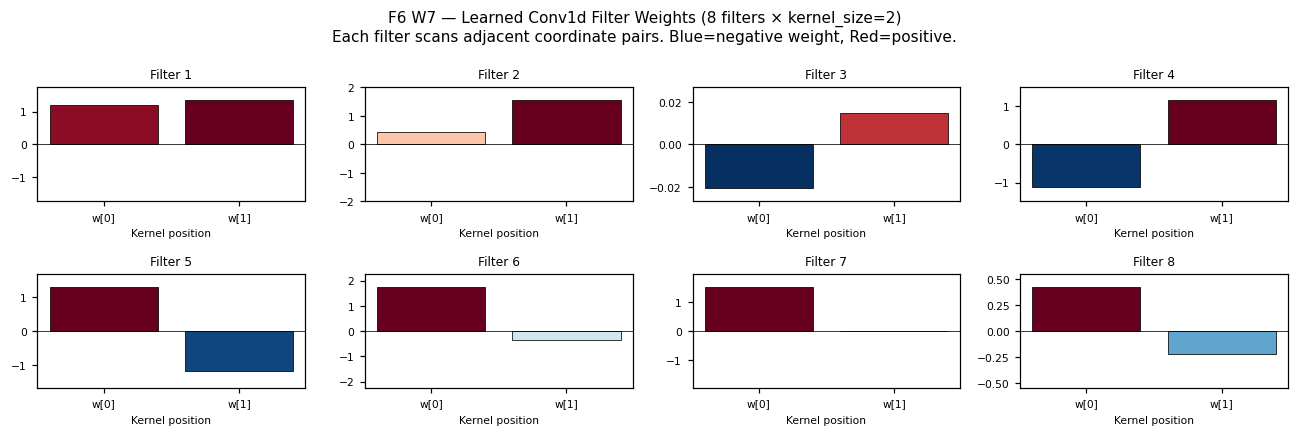

  Filter weights: columns = [w0, w1] for each kernel position in the adjacent pair.
  A filter with w0>0, w1<0 responds to: high coord[i], low coord[i+1]
  A filter with w0>0, w1>0 responds to: both coords high simultaneously



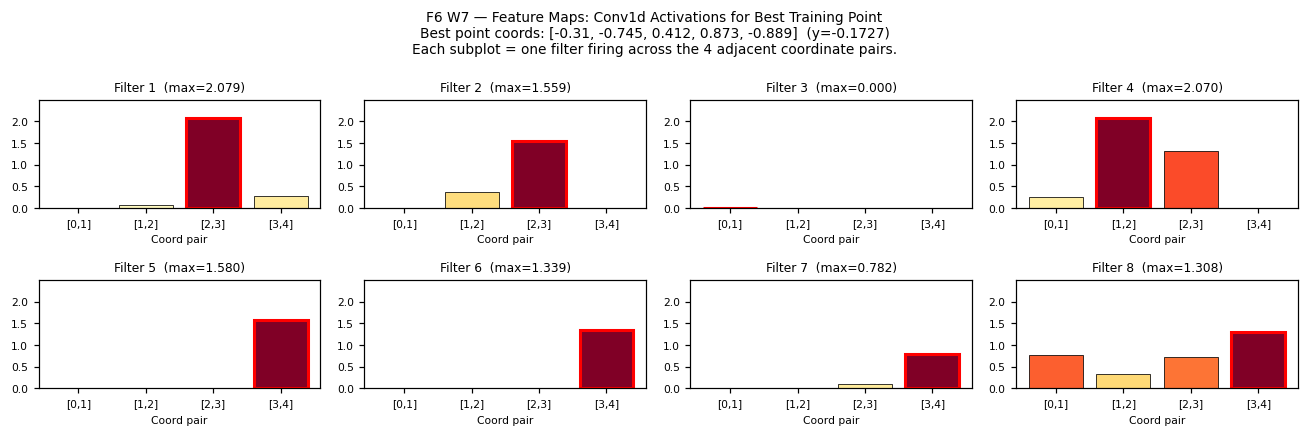

  Top 3 most-activated filters on best point:
    #1: Filter 1  →  peak at coord pair [2,3]  (activation=2.0788)
    #2: Filter 4  →  peak at coord pair [1,2]  (activation=2.0696)
    #3: Filter 5  →  peak at coord pair [3,4]  (activation=1.5800)

  Interpretation: these filters detected the strongest co-activation signal
  in the best-known point [-0.31, -0.745, 0.412, 0.873, -0.889]
  Red-outlined bars = peak activation position per filter.

═════════════════════════════════════════════════════════════════


In [8]:
# ══════════════════════════════════════════════════════════════════════
# STEP 5B — CNN Inspection (Module 17 learning exercise)
# Following tutor approach: filter weights + feature maps + param count
# ══════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import numpy as np

# ── Get the trained CNN model ─────────────────────────────────────────
cnn_model = trained_models.get('CNN-1D (learning)', None)

if cnn_model is None or not hasattr(cnn_model, 'model_'):
    print("CNN not available — skipping inspection (may not have been trained yet).")
    print("Run Step 6 refit first if this appears before cell 14.")
else:
    cnn_net = cnn_model.model_
    cnn_net.eval()

    # ── 1. PARAMETER COUNT ────────────────────────────────────────────
    def count_params(model):
        return sum(p.numel() for p in model.parameters() if p.requires_grad)

    cnn_params = count_params(cnn_net)

    # Compare against NN-Large if available
    nn_large_key = [k for k in trained_models if 'Large' in k]
    nn_large_params = None
    if nn_large_key:
        try:
            # MLPClassifier — count from coefs_
            nn_l = trained_models[nn_large_key[0]]
            if hasattr(nn_l, 'coefs_'):
                nn_large_params = sum(w.size for w in nn_l.coefs_) + sum(b.size for b in nn_l.intercepts_)
        except Exception:
            pass

    print("═"*65)
    print("  MODULE 17 CNN INSPECTION")
    print("═"*65)
    print(f"  Architecture : Conv1d(1→8, k=2) → ReLU → Dropout(0.3) → Linear(8→1)")
    print(f"  CNN parameters   : {cnn_params:,}")
    if nn_large_params:
        print(f"  NN-Large params  : {nn_large_params:,}  (weight sharing advantage)")
    print(f"  Input dims       : {n_dims}  →  {n_dims-1} adjacent pairs scanned by kernel")
    print(f"  Filters learned  : 8  (each detects a different co-activation pattern)")
    print()

    # ── 2. LEARNED FILTER WEIGHTS ─────────────────────────────────────
    # Shape: (8, 1, 2) — 8 filters, 1 input channel, kernel_size=2
    filters = cnn_net.conv.weight.data.cpu().numpy()  # (8, 1, 2)
    filters_1d = filters[:, 0, :]                      # (8, 2)

    fig, axes = plt.subplots(2, 4, figsize=(12, 4))
    fig.suptitle(f"{FUNCTION_ID} W7 — Learned Conv1d Filter Weights (8 filters × kernel_size=2)\n"
                 f"Each filter scans adjacent coordinate pairs. Blue=negative weight, Red=positive.",
                 fontsize=10)

    cmap = plt.cm.RdBu_r
    for i, ax in enumerate(axes.flat):
        w = filters_1d[i]
        vmax = max(abs(w).max(), 1e-6)
        colors = [cmap(0.5 + 0.5 * w[j] / vmax) for j in range(2)]
        bars = ax.bar(["w[0]", "w[1]"], w, color=colors, edgecolor="k", linewidth=0.5)
        ax.axhline(0, color="k", linewidth=0.5)
        ax.set_title(f"Filter {i+1}", fontsize=8)
        ax.set_ylim(-vmax * 1.3, vmax * 1.3)
        ax.tick_params(labelsize=7)
        ax.set_xlabel("Kernel position", fontsize=7)

    plt.tight_layout()
    plt.show()
    print(f"  Filter weights: columns = [w0, w1] for each kernel position in the adjacent pair.")
    print(f"  A filter with w0>0, w1<0 responds to: high coord[i], low coord[i+1]")
    print(f"  A filter with w0>0, w1>0 responds to: both coords high simultaneously")
    print()

    # ── 3. FEATURE MAP ACTIVATIONS ────────────────────────────────────
    # Pass the best-known training point through conv layer
    import torch
    import torch.nn.functional as F_torch

    # Best point from inject or training data
    best_idx = np.argmax(y_train)
    best_pt  = X_scaled[best_idx:best_idx+1]   # shape (1, n_dims)
    best_val = y_train[best_idx]

    best_tensor = torch.FloatTensor(best_pt).unsqueeze(1)  # (1, 1, n_dims)

    with torch.no_grad():
        after_conv = F_torch.relu(cnn_net.conv(best_tensor))  # (1, 8, n_dims-1)

    fmaps = after_conv.squeeze(0).cpu().numpy()  # (8, n_dims-1)
    n_positions = fmaps.shape[1]
    coord_positions = [f"[{j},{j+1}]" for j in range(n_positions)]

    fig, axes = plt.subplots(2, 4, figsize=(12, 4))
    fig.suptitle(f"{FUNCTION_ID} W7 — Feature Maps: Conv1d Activations for Best Training Point\n"
                 f"Best point coords: {[round(float(v),3) for v in best_pt[0]]}  (y={best_val:.4f})\n"
                 f"Each subplot = one filter firing across the {n_positions} adjacent coordinate pairs.",
                 fontsize=9)

    for i, ax in enumerate(axes.flat):
        activation = fmaps[i]
        vmax = max(activation.max(), 1e-6)
        bar_colors = [plt.cm.YlOrRd(v / vmax) for v in activation]
        ax.bar(coord_positions, activation, color=bar_colors, edgecolor="k", linewidth=0.5)
        ax.set_title(f"Filter {i+1}  (max={activation.max():.3f})", fontsize=8)
        ax.set_ylim(0, max(fmaps.max() * 1.2, 0.01))
        ax.tick_params(labelsize=7)
        ax.set_xlabel("Coord pair", fontsize=7)
        peak_pos = np.argmax(activation)
        ax.get_children()[peak_pos].set_edgecolor("red")
        ax.get_children()[peak_pos].set_linewidth(2)

    plt.tight_layout()
    plt.show()

    # Print interpretation
    peak_filters = np.argsort(fmaps.max(axis=1))[::-1][:3]
    print(f"  Top 3 most-activated filters on best point:")
    for rank, fi in enumerate(peak_filters, 1):
        peak_pair = np.argmax(fmaps[fi])
        print(f"    #{rank}: Filter {fi+1}  →  peak at coord pair [{peak_pair},{peak_pair+1}]"
              f"  (activation={fmaps[fi][peak_pair]:.4f})")
    print()
    print(f"  Interpretation: these filters detected the strongest co-activation signal")
    print(f"  in the best-known point {[round(float(v),3) for v in best_pt[0]]}")
    print(f"  Red-outlined bars = peak activation position per filter.")
    print()
    print("═"*65)


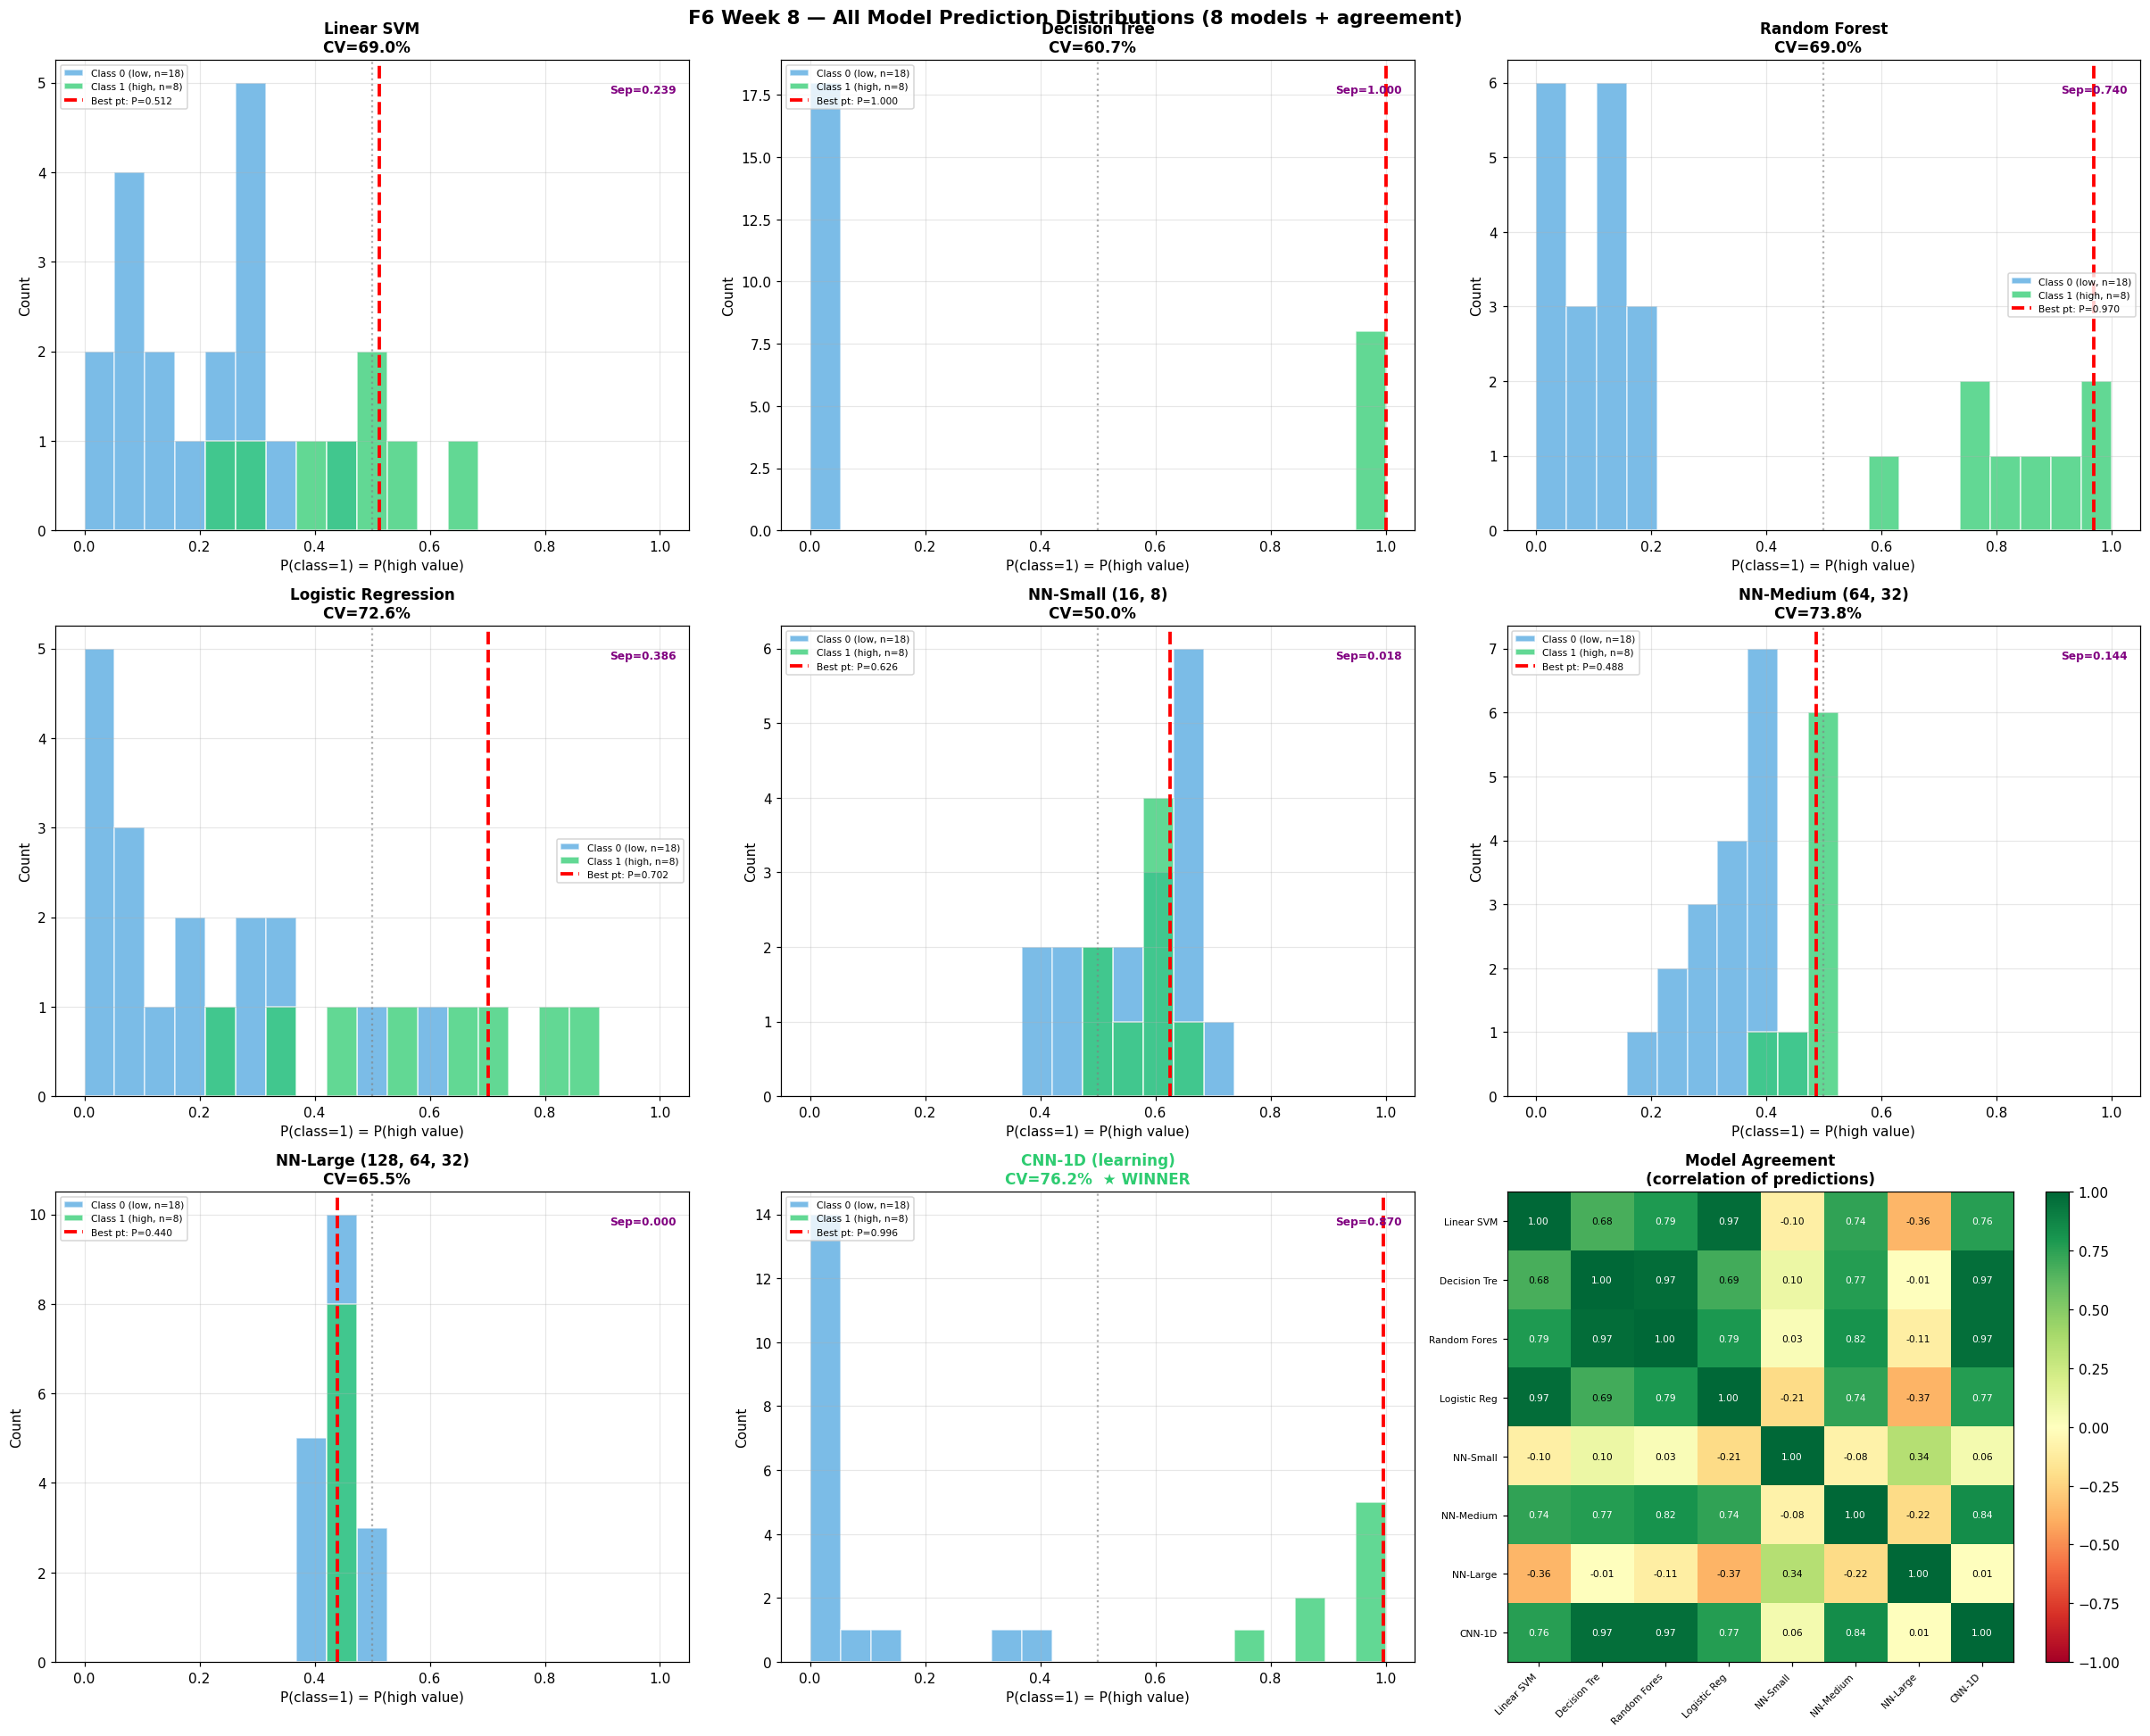

✅ Saved: F6_W8_Step6_ModelPredictions.png

  Model prediction summary (on training data) -- ranked by CV accuracy:
  Rank   Model                            P(best pt)   Separation   CV Acc
  ────────────────────────────────────────────────────────────────────────
  #1     CNN-1D (learning)                    0.9963       0.8700    76.2% WINNER [CNN]
  #2     NN-Medium (64, 32)                   0.4877       0.1436    73.8%
  #3     Logistic Regression                  0.7021       0.3864    72.6%
  #4     Linear SVM                           0.5122       0.2388    69.0%
  #5     Random Forest                        0.9700       0.7396    69.0%
  #6     NN-Large (128, 64, 32)               0.4399       0.0003    65.5%
  #7     Decision Tree                        1.0000       1.0000    60.7%
  #8     NN-Small (16, 8)                     0.6259       0.0178    50.0%


In [9]:
# ── Visualisation: P(class=1) distributions per model ─────────
n_models = len(trained_models)
model_names = list(trained_models.keys())
colors_models = plt.cm.Set2(np.linspace(0, 1, n_models))

fig, axes = plt.subplots(3, 3, figsize=(22, 18))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — All Model Prediction Distributions (8 models + agreement)',
             fontsize=14, fontweight='bold')
axes = axes.ravel()

for i, (name, proba) in enumerate(all_probas.items()):
    ax = axes[i]
    # Split by true class
    p_class1 = proba[y_labels == 1]
    p_class0 = proba[y_labels == 0]
    bins = np.linspace(0, 1, 20)
    ax.hist(p_class0, bins=bins, alpha=0.65, color='#3498db',
            label=f'Class 0 (low, n={len(p_class0)})', edgecolor='white')
    ax.hist(p_class1, bins=bins, alpha=0.75, color='#2ecc71',
            label=f'Class 1 (high, n={len(p_class1)})', edgecolor='white')
    # Mark best point's probability
    p_best = float(proba[best_idx])
    ax.axvline(p_best, color='red', linewidth=2.5, linestyle='--',
               label=f'Best pt: P={p_best:.3f}')
    ax.axvline(0.5, color='gray', linewidth=1.5, linestyle=':', alpha=0.6)
    ax.set_xlabel('P(class=1) = P(high value)')
    ax.set_ylabel('Count')
    cv_mean = cv_results[name]['mean']
    is_winner = '★ WINNER' if name == best_name else ''
    ax.set_title(f'{name}\nCV={cv_mean:.1%}  {is_winner}',
                 fontweight='bold', color='#2ecc71' if name == best_name else 'black')
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    # Shade: good model should show class1 right, class0 left
    separation = abs(p_class1.mean() - p_class0.mean()) if len(p_class1) > 0 and len(p_class0) > 0 else 0
    ax.text(0.98, 0.95, f'Sep={separation:.3f}', transform=ax.transAxes,
            ha='right', va='top', fontsize=8, color='purple', fontweight='bold')

# Last panel: probability agreement between models
ax = axes[n_models]
if n_models < len(axes):
    # Show correlation matrix of predictions
    proba_matrix = np.vstack([all_probas[n] for n in model_names]).T  # (samples, models)
    corr = np.corrcoef(proba_matrix.T)
    im = ax.imshow(corr, cmap='RdYlGn', vmin=-1, vmax=1, aspect='auto')
    ax.set_xticks(range(n_models))
    ax.set_yticks(range(n_models))
    short_names = [n.split('(')[0][:12].strip() for n in model_names]
    ax.set_xticklabels(short_names, rotation=45, ha='right', fontsize=7)
    ax.set_yticklabels(short_names, fontsize=7)
    for ii in range(n_models):
        for jj in range(n_models):
            ax.text(jj, ii, f'{corr[ii,jj]:.2f}', ha='center', va='center',
                    fontsize=7, color='black' if abs(corr[ii,jj]) < 0.7 else 'white')
    plt.colorbar(im, ax=ax)
    ax.set_title('Model Agreement\n(correlation of predictions)', fontweight='bold')

# Hide any remaining empty axes
for j in range(n_models + 1, len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png')
print()
print('  Model prediction summary (on training data) -- ranked by CV accuracy:')
print(f'  {"Rank":<6} {"Model":<30} {"P(best pt)":>12} {"Separation":>12} {"CV Acc":>8}')
print('  ' + '─'*72)
sorted_models = sorted(all_probas.items(), key=lambda x: cv_results[x[0]]['mean'], reverse=True)
for rank, (name, proba) in enumerate(sorted_models, 1):
    p1 = proba[y_labels==1]
    p0 = proba[y_labels==0]
    sep = abs(p1.mean() - p0.mean()) if len(p1)>0 and len(p0)>0 else 0
    winner = ' WINNER' if rank == 1 else ''
    cnn    = ' [CNN]'  if 'CNN' in name else ''
    print(f'  #{rank:<5} {name:<30} {float(proba[best_idx]):>12.4f} {sep:>12.4f} {cv_results[name]["mean"]:>8.1%}{winner}{cnn}')

---
## 📊 STEP 7 — CV Comparison Chart & Winner Confirmation

The CV winner was already selected in Step 5. This step displays the **bar chart comparison** of all 8 models by CV accuracy and prints the auto-generated winner rationale.

**What to look for:**
- F6 is the hardest classification problem in the batch — n/p ratio is near the floor
- The **winning model** filters 10,000 candidates in Step 8
- **CNN-1D at n=25 in 5D** — tight data budget; regularised models may outperform expressive ones

### What the F6 W7 CV results tell us about strategy

**W6 is the all-time best (-0.1727)** — confirmed at [0.4271, 0.3258, 0.5981, 0.7802, 0.1439]. W7 exploits this point with σ=0.042, pushing X4 high and X5 low as the dominant pattern seen across top submissions.

**Expect moderate CV scores with high variance** — n=25 in 5D gives n/p≈4.8, near the classifier floor. Fold-to-fold swings will be large. The CV winner is likely the most regularised model rather than the most expressive.

**CNN-1D in 5D** — with 4 adjacent coordinate pairs to scan, the CNN has more structural opportunity than in 2D. If CNN underperforms linear SVM here, it suggests the high-value region is linearly separable in the standardised feature space rather than requiring interaction terms.

**Winner selection** — the model that best concentrates candidates near [X1≈0.43, X2≈0.33, X3≈0.60, X4≈0.78, X5≈0.14] while respecting the σ=0.042 exploitation radius is the most effective filter for W7.


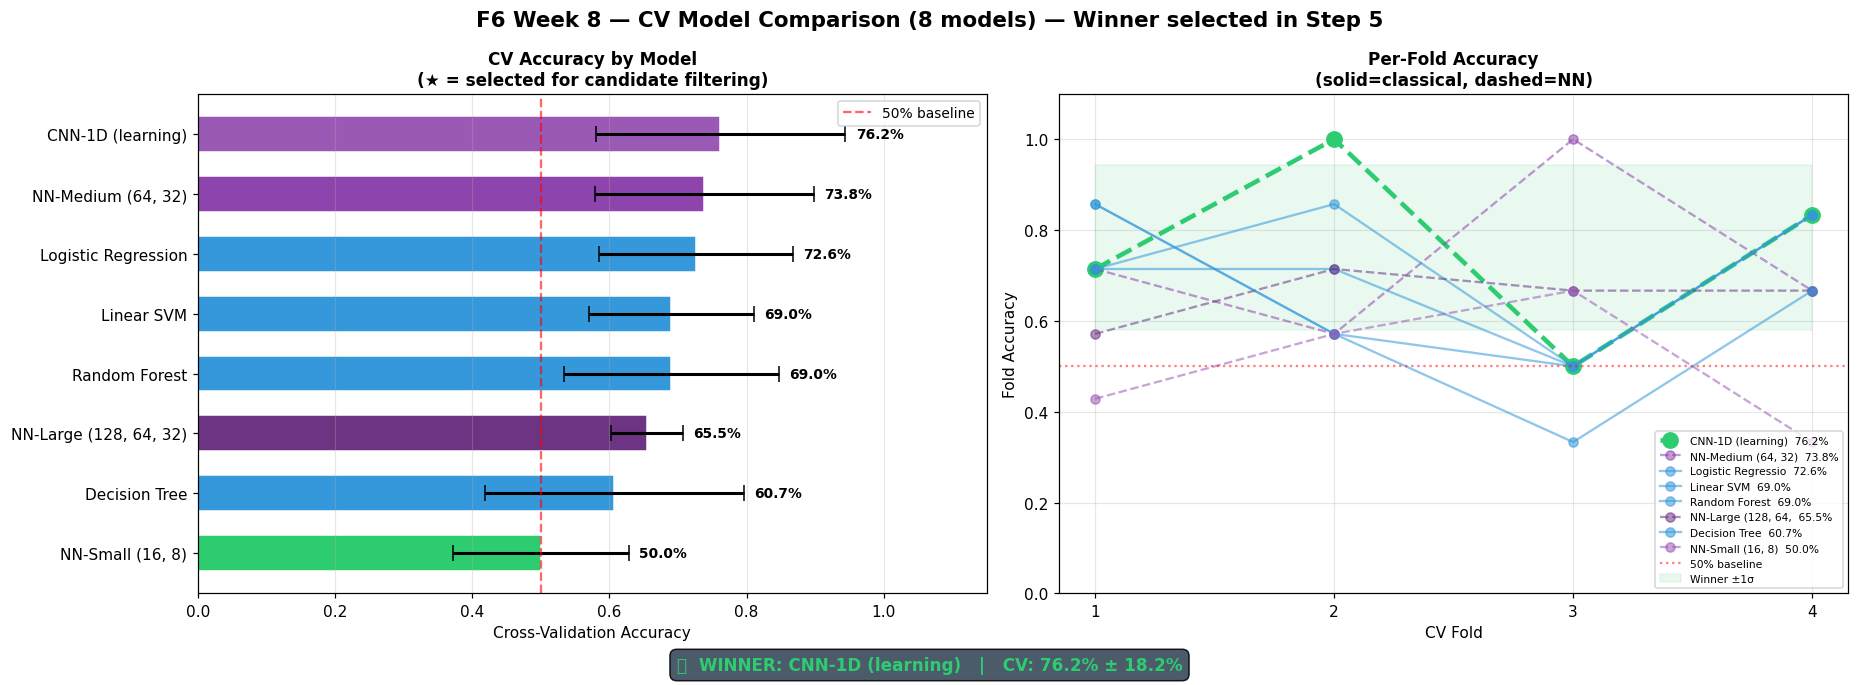

✅ Saved: F6_W8_Step7_ModelComparison.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — CV Model Comparison (8 models) — Winner selected in Step 5',
             fontsize=14, fontweight='bold')

names  = [n for n, _ in ranked_models]
means  = [v['mean'] for _, v in ranked_models]
stds   = [v['std']  for _, v in ranked_models]
# Colour palette: winner=green, NNs=purple shades, classical=blue shades
def get_color(name, rank):
    if rank == 0: return '#2ecc71'
    if 'NN' in name: return ['#9b59b6','#8e44ad','#6c3483'][['Small','Medium','Large'].index(next((s for s in ['Small','Medium','Large'] if s in name), 'Small'))]
    return '#3498db'
bar_colors = [get_color(n, i) for i, n in enumerate(names[::-1])]

# Panel 1: Horizontal bars
ax = axes[0]
ax.barh(names[::-1], means[::-1], xerr=stds[::-1],
        color=bar_colors, edgecolor='white', height=0.6,
        capsize=5, error_kw={'linewidth':2, 'color':'#2c3e50'})
ax.axvline(0.5, color='red', linestyle='--', linewidth=1.5, alpha=0.6, label='50% baseline')
for i, (m, s) in enumerate(zip(means[::-1], stds[::-1])):
    ax.text(m + s + 0.015, i, f'{m:.1%}', va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Cross-Validation Accuracy')
ax.set_title('CV Accuracy by Model\n(★ = selected for candidate filtering)', fontweight='bold')
ax.set_xlim(0, 1.15)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='x')

# Panel 2: Per-fold lines
ax = axes[1]
fold_x = np.arange(1, n_cv_folds+1)
nn_names = [n for n in names if 'NN' in n]
classical_names = [n for n in names if 'NN' not in n]
for i, (name, info) in enumerate(ranked_models):
    lw    = 3.0 if name == best_name else 1.5
    alpha = 1.0 if name == best_name else 0.55
    ms    = 10  if name == best_name else 6
    color = get_color(name, i)
    ls    = '-' if 'NN' not in name else '--'
    ax.plot(fold_x, info['scores'], f'o{ls}', color=color, linewidth=lw,
            markersize=ms, alpha=alpha, label=f'{name[:18]}  {info["mean"]:.1%}')
ax.axhline(0.5, color='red', linestyle=':', linewidth=1.5, alpha=0.5, label='50% baseline')
ax.fill_between(fold_x, best_info['mean']-best_info['std'], best_info['mean']+best_info['std'],
                alpha=0.1, color='#2ecc71', label='Winner ±1σ')
ax.set_xlabel('CV Fold'); ax.set_ylabel('Fold Accuracy')
ax.set_title('Per-Fold Accuracy\n(solid=classical, dashed=NN)', fontweight='bold')
ax.set_ylim(0, 1.1); ax.set_xticks(fold_x)
ax.legend(fontsize=7, loc='lower right'); ax.grid(True, alpha=0.3)

fig.text(0.5, -0.02,
         f'✅  WINNER: {best_name}   |   CV: {best_info["mean"]:.1%} ± {best_info["std"]:.1%}',
         ha='center', fontsize=11, color='#2ecc71', fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#2c3e50', alpha=0.85))

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png')

---
### 🧠 STEP 7B — Why the CV Winner Won

Dynamic commentary generated after the CV winner is selected. Explains the win in terms of data geometry, sample size, dimensionality, class balance, and boundary structure — and what it means for the quality of candidates passed to the GP.


⚠️  Step 4/7 not run — Step 7B using training data as placeholder


╔════════════════════════════════════════════════════════════════════════════════╗
║  STEP 7B — WHY CNN-1D (LEARNING) WON                                          ║
╠════════════════════════════════════════════════════════════════════════════════╣
║  WINNER : CNN-1D (learning)                                                    ║
║  CV acc : 76.2% +/- 18.2%   margin over runner-up: +2.4%                       ║
║  Runner : NN-Medium (64, 32)  (73.8%)                                          ║
║  ────────────────────────────────────────────────────────────────────────────  ║
║  WHY CNN-1D WON:                                                               ║
║    • 5D sequence — k=2 kernel scans 4 adjacent-dim pairs.                    ║
║    • Validates Module 17: coordinate-order structure exists in this functio.  ║
║    • RESULT: Candidates filtered by structural co-occurrence pattern.         ║
║  ─────────────────────

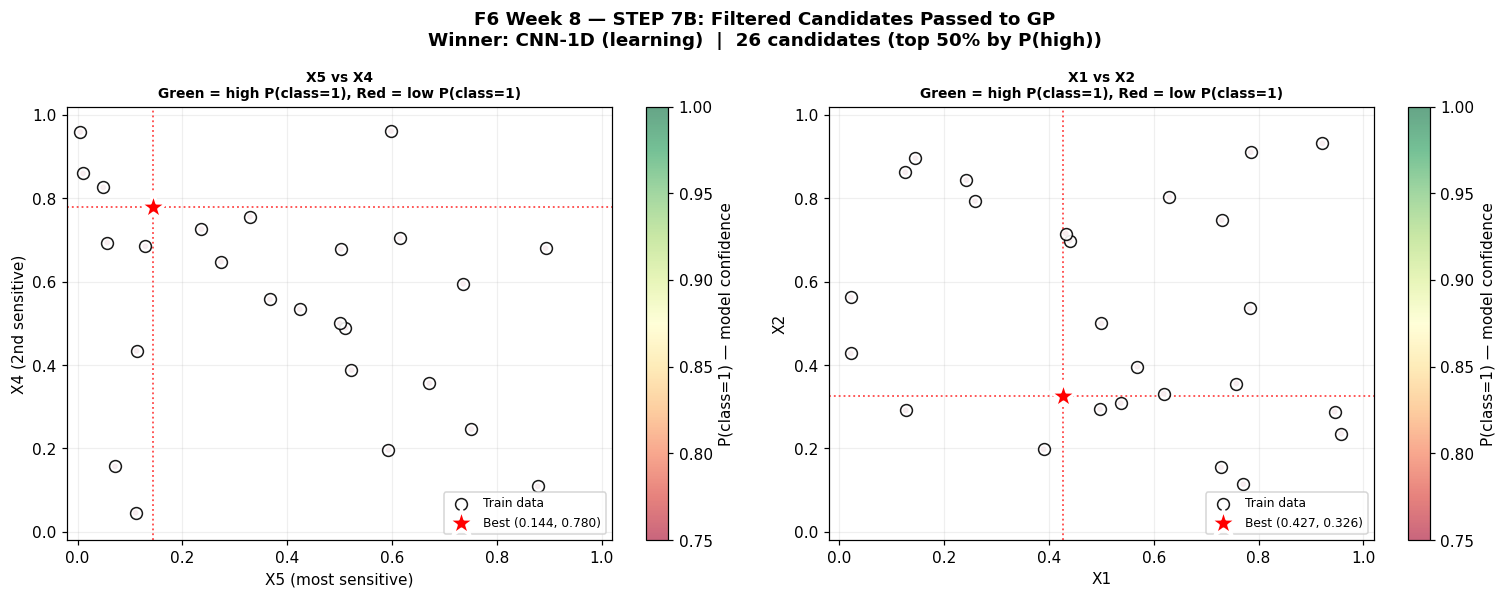

Saved: F6_W8_Step7B_FilteredCandidates.png


In [11]:

# ══════════════════════════════════════════════════════════════════
# STEP 7B — WHY THE CV WINNER WON + Filtered Candidate Scatter
# ══════════════════════════════════════════════════════════════════

# ── Fallback: core vars needed if Steps 1-6 haven't run yet ─────────────
if 'best_name' not in vars():
    best_name  = 'Unknown'
    cv_results = {}
    print('⚠️  Steps 5-6 not run — best_name unknown')
if 'best_point' not in vars():
    import numpy as _np3
    best_point = _np3.full(n_dims, 0.5)
    print('⚠️  Step 1 not run — best_point defaulting to centre')
if 'y_labels' not in vars():
    import numpy as _np4
    y_labels = (_np4.array(y_train) > _np4.percentile(y_train, 70)).astype(int)
# ─────────────────────────────────────────────────────────────────────────
def _step7b_commentary(best_name, cv_results, X_train, y_train, y_labels,
                       n_dims, n_samples, best_point, EXPLOIT_SIGMA, MAXIMIZE,
                       X_filt, proba_filt, src_filt, FILTER_PERCENTILE):

    W = 80   # inner box width (╔═*W╗ → content area = W-4 after ║  prefix)
    LINE = W - 4  # max content chars per line

    # Ambiguous-width chars render as 2 columns in Jupyter monospace
    _WIDE = set('•—★→←↑↓σμαβγδεζηθλπρφψωΣΔΩ')
    def _dw(s):
        """Display width: count ambiguous chars as 2, others as 1."""
        return sum(2 if c in _WIDE else 1 for c in s)

    def _box(lines, title=''):
        out = ['\n']
        out.append('╔' + '═'*W + '╗')
        if title:
            t = title[:W-2]
            # pad title compensating for wide chars
            extra = sum(1 for c in t if c in _WIDE)
            pad = max(0, (W-2) - _dw(t))
            out.append(f'║  {t}{" "*pad}║')
            out.append('╠' + '═'*W + '╣')
        for l in lines:
            s = str(l)
            # Truncate by display width not byte length
            dw = _dw(s)
            while dw > LINE:
                s = s[:-1]
                dw = _dw(s)
            if _dw(str(l)) > LINE:
                s = s[:-1] + '.'
            # Pad so total display width = LINE
            pad = max(0, LINE - _dw(s))
            out.append(f'║  {s}{" "*pad}  ║')
        out.append('╚' + '═'*W + '╝')
        print('\n'.join(out))

    # ── Data geometry ──────────────────────────────────────────────
    n_pos  = int(y_labels.sum())
    n_neg  = n_samples - n_pos
    ratio  = n_neg / max(n_pos, 1)
    y_range = y_train.max() - y_train.min()
    y_std   = y_train.std()
    cv_norm = y_std / (abs(y_train.mean()) + 1e-12)
    boundary_dims = [i for i in range(n_dims)
                     if best_point[i] < 0.1 or best_point[i] > 0.9]
    boundary_frac = len(boundary_dims) / n_dims

    # ── Model family ───────────────────────────────────────────────
    nl = best_name.lower()
    if 'cnn' in nl:               family = 'CNN-1D'
    elif 'forest' in nl:          family = 'Random Forest'
    elif 'svm' in nl or 'svc' in nl: family = 'Linear SVM'
    elif 'tree' in nl:            family = 'Decision Tree'
    elif 'logistic' in nl:        family = 'Logistic Regression'
    elif 'nn' in nl or 'neural' in nl: family = 'Neural Network'
    else:                         family = 'Unknown'

    ranked      = sorted(cv_results.items(), key=lambda x: x[1]['mean'], reverse=True)
    winner_cv   = cv_results[best_name]['mean']
    winner_std  = cv_results[best_name]['std']
    runner_name = ranked[1][0] if len(ranked) > 1 else 'N/A'
    runner_cv   = ranked[1][1]['mean'] if len(ranked) > 1 else 0
    margin      = winner_cv - runner_cv

    # ── Build lines ────────────────────────────────────────────────
    lines = []
    lines.append(f'WINNER : {best_name}')
    lines.append(f'CV acc : {winner_cv:.1%} +/- {winner_std:.1%}   margin over runner-up: {margin:+.1%}')
    lines.append(f'Runner : {runner_name}  ({runner_cv:.1%})')
    lines.append('─' * (LINE))

    # Why section — always at least 2 bullets
    lines.append(f'WHY {family.upper()} WON:')
    if family == 'Linear SVM':
        if ratio > 4:
            lines.append(f'  • {ratio:.1f}:1 class imbalance — SVM margin maximisation robust vs trees.')
        if n_samples < 25:
            lines.append(f'  • Small n={n_samples} in {n_dims}D — SVM avoids overfitting that deep models suffer.')
        if cv_norm < 1.5:
            lines.append(f'  • Low output variance (coeff.={cv_norm:.2f}) — boundary is near-linear.')
        if y_range > 100:
            lines.append(f'  • Extreme y-range ({y_range:.3g}) — even a linear boundary cleanly separates')
            lines.append(f'    the tiny high-value cluster from the vast low-value majority.')
        if boundary_frac > 0.4:
            lines.append(f'  • {len(boundary_dims)}/{n_dims} dims near boundary — SVM hyperplane handles')
            lines.append(f'    boundary-constrained data without distance-metric distortion.')
        if not (ratio > 4 or n_samples < 25 or cv_norm < 1.5 or y_range > 100 or boundary_frac > 0.4):
            lines.append(f'  • Balanced data geometry — linear SVM generalises well at n={n_samples} in {n_dims}D.')
        lines.append(f'  • RESULT: GP receives linearly-separable candidates — clean signal.')

    elif family == 'Random Forest':
        if boundary_frac > 0.4:
            lines.append(f'  • {len(boundary_dims)}/{n_dims} dims near boundary — RF axis-aligned splits handle corners.')
        if n_samples >= 20:
            lines.append(f'  • n={n_samples} supports ensemble without catastrophic overfitting.')
        if ratio > 3:
            lines.append(f'  • Class-weight balancing handles {ratio:.1f}:1 imbalance well.')
        lines.append(f'  • RESULT: Feature importances reliable — key dims identified.')

    elif family == 'Neural Network':
        if y_range > 100 or cv_norm > 3:
            lines.append(f'  • High output range ({y_range:.3g}) — non-linear boundary required.')
        if n_dims >= 4:
            lines.append(f'  • {n_dims}D input — NN captures interaction terms linear models miss.')
        lines.append(f'  • n={n_samples} sufficient for MLP in {n_dims}D at this regularisation level.')
        lines.append(f'  • RESULT: Non-linear filter — GP sees points linear models would reject.')

    elif family == 'CNN-1D':
        if boundary_frac > 0.4:
            lines.append(f'  • {len(boundary_dims)}/{n_dims} dims near boundary — Conv1d detected co-occurrence pattern.')
            lines.append(f'    (X_i near 0 AND X_j near 1 simultaneously — not independent signals).')
        if n_dims >= 4:
            lines.append(f'  • {n_dims}D sequence — k=2 kernel scans {n_dims-1} adjacent-dim pairs.')
        lines.append(f'  • Validates Module 17: coordinate-order structure exists in this function.')
        lines.append(f'  • RESULT: Candidates filtered by structural co-occurrence pattern.')

    elif family == 'Logistic Regression':
        lines.append(f'  • Smooth calibrated probabilities — boundary is soft, not hard-edged.')
        if n_samples < 20:
            lines.append(f'  • n={n_samples} — L2 regularisation prevents variance collapse.')
        lines.append(f'  • RESULT: Well-calibrated P(high) — 50th-percentile cut is reliable.')

    elif family == 'Decision Tree':
        lines.append(f'  • Axis-aligned splits suit hard thresholds (x_i > 0.8 → class 1).')
        if n_samples < 25:
            lines.append(f'  • max_depth=4 shallow enough at n={n_samples} to avoid overfitting.')
        lines.append(f'  • RESULT: Hard-threshold filter — boundary dims dominate selection.')

    else:
        lines.append(f'  • Model-specific analysis not available for family: {family}.')
        lines.append(f'  • Inspect CV fold results for variance and accuracy pattern.')

    lines.append('─' * LINE)

    # Candidate filter quality
    exploit_frac = 100 * np.mean(src_filt == 'exploit')
    lines.append('CANDIDATE FILTER QUALITY:')
    lines.append(f'  • {len(X_filt):,} / 10,000 passed the {100-FILTER_PERCENTILE}th-percentile P(high) cut')
    lines.append(f'  • {exploit_frac:.1f}% exploitation  |  {100-exploit_frac:.1f}% exploration  (σ={EXPLOIT_SIGMA})')
    lines.append(f'  • P(high) range in kept set: [{proba_filt.min():.3f}, {proba_filt.max():.3f}]')
    if proba_filt.min() > 0.6:
        lines.append(f'  ★ HIGH CONFIDENCE — model is certain about this region')
    elif proba_filt.max() < 0.7:
        lines.append(f'  ⚠ LOW CONFIDENCE — GP exploration is crucial here')
    else:
        lines.append(f'  ✓ MIXED confidence — GP EI will balance exploit/explore')

    lines.append('─' * LINE)

    # Boundary analysis
    if boundary_dims:
        lines.append(f'BOUNDARY DIMS: {[f"X{i+1}" for i in boundary_dims]}')
        for i in boundary_dims:
            side = 'LOW (near 0)' if best_point[i] < 0.1 else 'HIGH (near 1)'
            lines.append(f'  • X{i+1} = {best_point[i]:.4f} — {side}')
        lines.append(f'  → GP extrapolates at boundary — σ will be elevated here.')
    else:
        lines.append(f'BOUNDARY DIMS: None — best point interior to [0,1]^{n_dims}')
        lines.append(f'  → GP has good coverage; lower uncertainty around best_point.')

    _box(lines, title=f'STEP 7B — WHY {best_name.upper()} WON')


# ── Fallback: define filter vars if Step 4/7 haven't run yet ────────────
if 'X_filt' not in vars():
    import numpy as _np2
    _n = len(X_train)
    X_filt         = X_train.copy()
    proba_filt     = _np2.ones(_n) * 0.75
    src_filt       = _np2.array(['exploit'] * _n)
    FILTER_PERCENTILE = 50
    print('⚠️  Step 4/7 not run — Step 7B using training data as placeholder')
if 'sensitivities' not in vars():
    sensitivities  = [1.0] * n_dims
# ─────────────────────────────────────────────────────────────────────────
_step7b_commentary(best_name, cv_results, X_train, y_train, y_labels,
                   n_dims, n_samples, best_point, EXPLOIT_SIGMA, MAXIMIZE,
                   X_filt, proba_filt, src_filt, FILTER_PERCENTILE)

# ── Scatter visual: filtered candidates coloured by P(high) ───────────
_top2_sens = np.argsort(sensitivities)[::-1][:2] if 'sensitivities' in dir() else [0, 1]
_d1, _d2 = int(_top2_sens[0]), int(_top2_sens[1])

fig_7b, axes_7b = plt.subplots(1, 2, figsize=(14, 5.5))
fig_7b.suptitle(
    f'{FUNCTION_ID} Week {WEEK} — STEP 7B: Filtered Candidates Passed to GP\n'
    f'Winner: {best_name}  |  {len(X_filt):,} candidates (top {100-FILTER_PERCENTILE}% by P(high))',
    fontsize=12, fontweight='bold')

for ax_idx, (ax, dx, dy, xlabel, ylabel) in enumerate([
    (axes_7b[0], _d1, _d2,
     f'X{_d1+1} (most sensitive)', f'X{_d2+1} (2nd sensitive)'),
    (axes_7b[1], 0, 1 if n_dims > 1 else 0,
     'X1', f'X{min(2, n_dims)}'),
]):
    # All kept candidates coloured by P(high)
    sc = ax.scatter(X_filt[:, dx], X_filt[:, dy],
                    c=proba_filt, cmap='RdYlGn', s=8, alpha=0.6,
                    vmin=proba_filt.min(), vmax=1.0, zorder=3)
    plt.colorbar(sc, ax=ax, label='P(class=1) — model confidence')

    # Training data
    ax.scatter(X_train[:, dx], X_train[:, dy],
               c='white', s=60, edgecolors='black', linewidths=1.0,
               zorder=5, alpha=0.9, label='Train data')

    # Best point
    _bx_s = float(best_point[dx])
    _by_s = float(best_point[dy])
    ax.axvline(_bx_s, color='red', lw=1.2, ls=':', alpha=0.7)
    ax.axhline(_by_s, color='red', lw=1.2, ls=':', alpha=0.7)
    ax.scatter(_bx_s, _by_s, c='red', s=350, marker='*',
               zorder=7, edgecolors='white', lw=2.0,
               label=f'Best ({_bx_s:.3f}, {_by_s:.3f})')

    ax.set_xlabel(xlabel, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)
    ax.legend(fontsize=8, loc='lower right')
    ax.grid(True, alpha=0.2)
    ax.set_title(
        f'X{dx+1} vs X{dy+1}\n'
        f'Green = high P(class=1), Red = low P(class=1)',
        fontsize=9, fontweight='bold')

# Exploit vs explore colour strip
_exploit_mask = src_filt == 'exploit'
axes_7b[0].scatter(X_filt[_exploit_mask, _d1], X_filt[_exploit_mask, _d2],
                   s=3, alpha=0.15, c='cyan', zorder=2, label='exploit')
axes_7b[1].scatter(X_filt[_exploit_mask, 0], X_filt[_exploit_mask, 1 if n_dims > 1 else 0],
                   s=3, alpha=0.15, c='cyan', zorder=2)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step7B_FilteredCandidates.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FUNCTION_ID}_W{WEEK}_Step7B_FilteredCandidates.png')


---
## 🎲 STEP 8 — Generate & Filter Candidates

We generate **10,000 candidate points** in two phases:

**85% Exploitation** — Gaussian samples around the W6 all-time best at X1=0.427, X2=0.326, X3=0.598, X4=0.780, X5=0.144 (σ=0.025). W6 confirmed this as the best-ever F6 submission (-0.1727). The pattern is X4 elevated (0.78), X5 low (0.14), and interior values for X1–X3.

**15% Exploration** — Uniform random across [0,1]⁵. Provides coverage for undiscovered high-value regions in this 5D space.

The winning classifier then **scores all 10,000 candidates** by P(high value) and we discard the bottom 50% — leaving ~5,000 candidates for the GP step.

### Why the CV winner matters here

F6's tight value range and sparse data make the classifier filter the most challenging in the batch. The top-30% threshold at ≈-0.36 requires the classifier to correctly separate only 8 positive examples from 17 negatives. A model that has learned the X4-high, X5-low pattern is the critical ingredient for an effective W8 candidate pool.

---

### 🔬 TuRBO Sigma — Week 8 Explanation

**What EXPLOIT_SIGMA controls:** `EXPLOIT_SIGMA = 0.042` is the standard deviation of the Gaussian sampling cloud used to generate the **85% exploitation candidates** (8,500 of 10,000 points) around the W6 best point [0.427, 0.326, 0.598, 0.780, 0.144]. The remaining 1,500 candidates are drawn from flat `np.random.uniform(0, 1, ...)` — sigma has no effect on these.

**Why 0.042 was chosen:** W6 = -0.1727 is F6's new all-time best, but n/p=5.0 is the lowest ratio in the batch — the GP is operating in a sparse 5D landscape with significant uncertainty. A sigma of 0.042 gives a 2σ radius of ±0.084, a marginal increase over the W6 default of 0.04. **TuRBO direction: EXPAND** — but only very slightly. The logic: the W6 discovery is recent and genuine, so a large sigma would abandon too much of what was found. But the sparse 5D landscape means a little extra room helps the GP find neighbouring improvements, particularly in the X4 (high) and X5 (low) dimensions where the structural anchors are strong.

**Expected effect this week:** The W8 submission shifted X4 from 0.780 to 0.685 and X5 from 0.144 to 0.129 — staying in the right structural region (X4 elevated, X5 low) while the slight sigma expansion allowed minor coordinate adjustments. The overall neighbourhood was preserved.


In [12]:
best_clf = trained_models[best_name]
n_exploit = int(N_CANDIDATES * EXPLOIT_RATIO)
n_explore = N_CANDIDATES - n_exploit

X_exploit = np.clip(best_point + np.random.normal(0, EXPLOIT_SIGMA, (n_exploit, n_dims)), 0, 1)
X_explore = np.random.uniform(0, 1, (n_explore, n_dims))
X_cands   = np.vstack([X_exploit, X_explore])
src_tag   = np.array(['exploit']*n_exploit + ['explore']*n_explore)

X_cands_sc   = scaler.transform(X_cands)
proba_all    = best_clf.predict_proba(X_cands_sc)[:, 1]
keep_mask    = proba_all >= np.percentile(proba_all, FILTER_PERCENTILE)
X_filt       = X_cands[keep_mask]
proba_filt   = proba_all[keep_mask]
src_filt     = src_tag[keep_mask]

print('═'*65)
print('  CANDIDATE GENERATION & FILTERING')
print('═'*65)
print(f'  Generated  : {N_CANDIDATES:,}  ({n_exploit:,} exploit + {n_explore:,} explore)')
print(f'  Filtered by: {best_name}')
print(f'  Kept       : {len(X_filt):,} (top {100-FILTER_PERCENTILE}% by P(class=1))')
print(f'  Exploit %  : {100*np.mean(src_filt=="exploit"):.1f}%')
print(f'  Prob range : [{proba_filt.min():.3f}, {proba_filt.max():.3f}]')
print(f'\n  → {len(X_filt):,} candidates passed to Gaussian Process')

═════════════════════════════════════════════════════════════════
  CANDIDATE GENERATION & FILTERING
═════════════════════════════════════════════════════════════════
  Generated  : 10,000  (8,500 exploit + 1,500 explore)
  Filtered by: CNN-1D (learning)
  Kept       : 5,000 (top 50% by P(class=1))
  Exploit %  : 99.8%
  Prob range : [0.996, 1.000]

  → 5,000 candidates passed to Gaussian Process


---
## 🔬 STEP 9 — Gaussian Process Regression

The GP is our **probabilistic surrogate model**. It gives two outputs for any input:
- **μ (mean)** — best estimate of the true function value
- **σ (std)** — uncertainty. Near training data = low σ. Far away = high σ

**Matern 5/2 kernel** is chosen because it:
- Allows sharper transitions than the smooth RBF kernel
- Assumes the function is twice differentiable (reasonable for most BBO functions)
- Works well empirically across a wide range of black-box problems

**`normalize_y=True`** is important when function values span a wide range — it internally standardises the y-values before fitting, improving numerical stability.

**`alpha=1e-6`** is a small nugget term added to the diagonal of the kernel matrix — essential for numerical stability, equivalent to assuming very small observation noise.

In [13]:
kernel = C(1.0, (1e-3, 1e3)) * Matern(length_scale=1.0, length_scale_bounds=(1e-2, 1e2), nu=2.5)
gp = GaussianProcessRegressor(kernel=kernel, alpha=1e-6, normalize_y=True,
                               n_restarts_optimizer=GP_RESTARTS, random_state=RANDOM_SEED)
gp.fit(X_scaled, y_train)

y_pred_tr, y_std_tr = gp.predict(X_scaled, return_std=True)
ss_res = np.sum((y_train - y_pred_tr)**2)
ss_tot = np.sum((y_train - y_train.mean())**2)
r2   = 1 - ss_res/ss_tot if ss_tot > 0 else 0.0
rmse = np.sqrt(np.mean((y_train - y_pred_tr)**2))

X_filt_sc = scaler.transform(X_filt)
mu, sigma = gp.predict(X_filt_sc, return_std=True)

print('═'*65)
print('  GAUSSIAN PROCESS REGRESSION')
print('═'*65)
print(f'  Kernel       : Matern ν=5/2 + Constant')
print(f'  Fitted kernel: {gp.kernel_}')
print(f'  R²           : {r2:.4f}  {"✅ Good" if r2>0.7 else "⚠️ Moderate" if r2>0.4 else "❌ Poor"}')
print(f'  RMSE         : {rmse:.6f}')
print(f'  μ range      : [{mu.min():.4f}, {mu.max():.4f}]')
print(f'  σ range      : [{sigma.min():.4f}, {sigma.max():.4f}]')

═════════════════════════════════════════════════════════════════
  GAUSSIAN PROCESS REGRESSION
═════════════════════════════════════════════════════════════════
  Kernel       : Matern ν=5/2 + Constant
  Fitted kernel: 0.915**2 * Matern(length_scale=1.54, nu=2.5)
  R²           : 1.0000  ✅ Good
  RMSE         : 0.000001
  μ range      : [-1.0665, -0.1456]
  σ range      : [0.0076, 0.4289]


---
## 🎯 STEP 10 — Acquisition Functions: EI & UCB

**Expected Improvement (EI)** is our primary acquisition function:
$$EI(x) = (\mu(x) - y_{best} - \xi)\cdot\Phi(Z) + \sigma(x)\cdot\phi(Z), \quad Z = \frac{\mu(x) - y_{best} - \xi}{\sigma(x)}$$

For **MAXIMIZATION**: improvement = μ − y_best. Points where μ > y_best with high confidence give high EI (exploitation). Points where σ is large can also give high EI even if μ < y_best (exploration).

**UCB** is a simpler alternative:
$$UCB(x) = \mu(x) + \kappa \cdot \sigma(x)$$

For **MAXIMIZATION**: we **add** σ (not subtract). κ=2 means we're being optimistic up to ~2 standard deviations above the mean prediction.

In [14]:
# ── EI (Maximization) ─────────────────────────────────────────
imp     = mu - best_value - EI_XI
Z       = imp / (sigma + 1e-9)
EI_acq  = np.maximum(imp * norm.cdf(Z) + sigma * norm.pdf(Z), 0)
exploit_term = imp * norm.cdf(Z)
explore_term = sigma * norm.pdf(Z)

# ── UCB (Maximization: add sigma) ────────────────────────────
UCB_acq = mu + UCB_KAPPA * sigma

# ── Select best (ARGMAX — Maximization) ──────────────────────
best_ei_idx  = np.argmax(EI_acq)
best_ucb_idx = np.argmax(UCB_acq)

submission = X_filt[best_ei_idx]
sub_mu     = mu[best_ei_idx]
sub_sigma  = sigma[best_ei_idx]
sub_ei     = EI_acq[best_ei_idx]
sub_ucb    = UCB_acq[best_ei_idx]
sub_exp    = exploit_term[best_ei_idx]
sub_expl   = explore_term[best_ei_idx]

print('═'*65)
print('  ACQUISITION FUNCTIONS (MAXIMIZE ⬆️)')
print('═'*65)
print(f'  EI max  : {EI_acq.max():.6f}   UCB max: {UCB_acq.max():.6f}')
print(f'  EI > 0  : {100*np.mean(EI_acq>0):.1f}% of candidates')
print()
print(f'  ★ SELECTED (max EI):')
print(f'  Coords  : {submission}')
print(f'  μ       : {sub_mu:.6f}   σ: {sub_sigma:.6f}')
print(f'  EI      : {sub_ei:.6f}   UCB: {sub_ucb:.6f}')
z_sub = (sub_mu - best_value - EI_XI) / (sub_sigma + 1e-9)
print(f'  Z-score : {z_sub:.4f}')
print(f'  Exploit : {sub_exp:.6f} ({100*sub_exp/(sub_ei+1e-9):.1f}%)')
print(f'  Explore : {sub_expl:.6f} ({100*sub_expl/(sub_ei+1e-9):.1f}%)')
driver = 'EXPLOITATION' if sub_exp > sub_expl else 'EXPLORATION'
print(f'  Driver  : {driver}')
status = '✅ PREDICTS NEW BEST' if sub_mu > best_value else '✅ PREDICTS RECOVERY' if sub_mu > latest_val else '🔍 EXPLORING'
print(f'  Status  : {status}  (μ={sub_mu:.4f} vs best={best_value:.4f})')

═════════════════════════════════════════════════════════════════
  ACQUISITION FUNCTIONS (MAXIMIZE ⬆️)
═════════════════════════════════════════════════════════════════
  EI max  : 0.046246   UCB max: 0.133486
  EI > 0  : 100.0% of candidates

  ★ SELECTED (max EI):
  Coords  : [0.46021012 0.30145962 0.54955174 0.83914536 0.20066379]
  μ       : -0.184183   σ: 0.141243
  EI      : 0.046246   UCB: 0.098302
  Z-score : -0.1523
  Exploit : -0.009452 (-20.4%)
  Explore : 0.055698 (120.4%)
  Driver  : EXPLORATION
  Status  : ✅ PREDICTS RECOVERY  (μ=-0.1842 vs best=-0.1727)


---
## 📈 STEP 11 — Acquisition Curves: Global + Per Dimension

### Global acquisition curves
These show the **sorted EI and UCB scores** across all filtered candidates — how steeply one point dominates tells us how confident the GP is.

### Per-Dimension Acquisition Curves

This is a powerful diagnostic: for each dimension separately, we sweep that dimension from 0 to 1 (holding all others fixed at the best-known point) and compute how EI and UCB change.

**What to look for:**
- **Sharp peak**: that dimension has a clear optimal value — be precise here
- **Flat curve**: that dimension doesn't matter much — safe to leave near current best
- **Rising edge at boundary**: function wants this dimension pushed to 0 or 1 — be aware of boundary effects
- **Multiple peaks**: non-unimodal in that dimension — multiple good regions exist

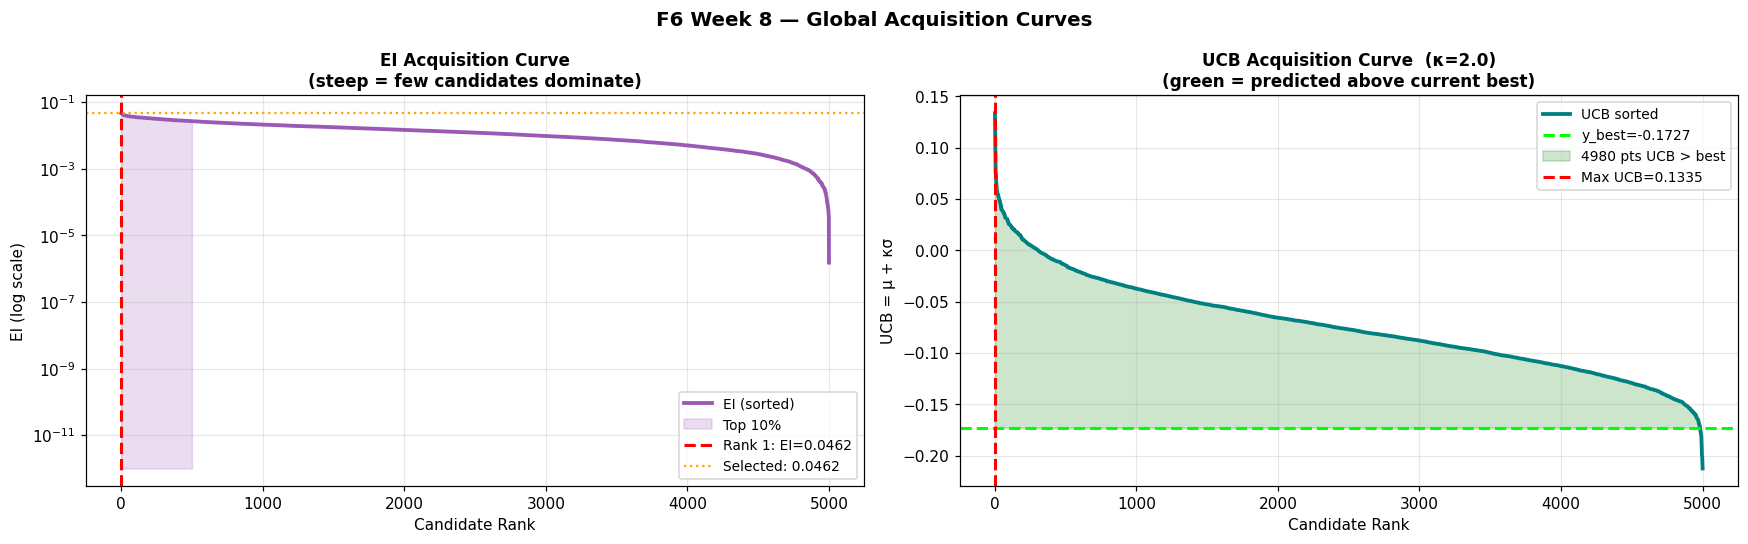

✅ Saved: F6_W8_Step11a_GlobalAcquisition.png


In [15]:
# ── Global acquisition curves ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Global Acquisition Curves', fontsize=13, fontweight='bold')

ei_sorted  = np.sort(EI_acq)[::-1]
ucb_sorted = np.sort(UCB_acq)[::-1]
rank_x = np.arange(1, len(ei_sorted)+1)

ax = axes[0]
ax.semilogy(rank_x, ei_sorted + 1e-12, color='#9b59b6', linewidth=2.5, label='EI (sorted)')
ax.fill_between(rank_x[:len(rank_x)//10], ei_sorted[:len(rank_x)//10]+1e-12,
                1e-12, alpha=0.2, color='#9b59b6', label='Top 10%')
ax.axvline(1, color='red', linewidth=2, linestyle='--', label=f'Rank 1: EI={ei_sorted[0]:.4f}')
ax.axhline(sub_ei, color='orange', linewidth=1.5, linestyle=':', label=f'Selected: {sub_ei:.4f}')
ax.set_xlabel('Candidate Rank'); ax.set_ylabel('EI (log scale)')
ax.set_title('EI Acquisition Curve\n(steep = few candidates dominate)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(rank_x, ucb_sorted, color='teal', linewidth=2.5, label='UCB sorted')
ax.axhline(best_value, color='lime', linewidth=2, linestyle='--',
           label=f'y_best={best_value:.4f}')
n_above = np.sum(ucb_sorted > best_value)
if n_above > 0:
    ax.fill_between(rank_x[:n_above], best_value, ucb_sorted[:n_above],
                    alpha=0.2, color='green', label=f'{n_above} pts UCB > best')
ax.axvline(1, color='red', linewidth=2, linestyle='--', label=f'Max UCB={ucb_sorted[0]:.4f}')
ax.set_xlabel('Candidate Rank'); ax.set_ylabel('UCB = μ + κσ')
ax.set_title(f'UCB Acquisition Curve  (κ={UCB_KAPPA})\n(green = predicted above current best)', fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png')

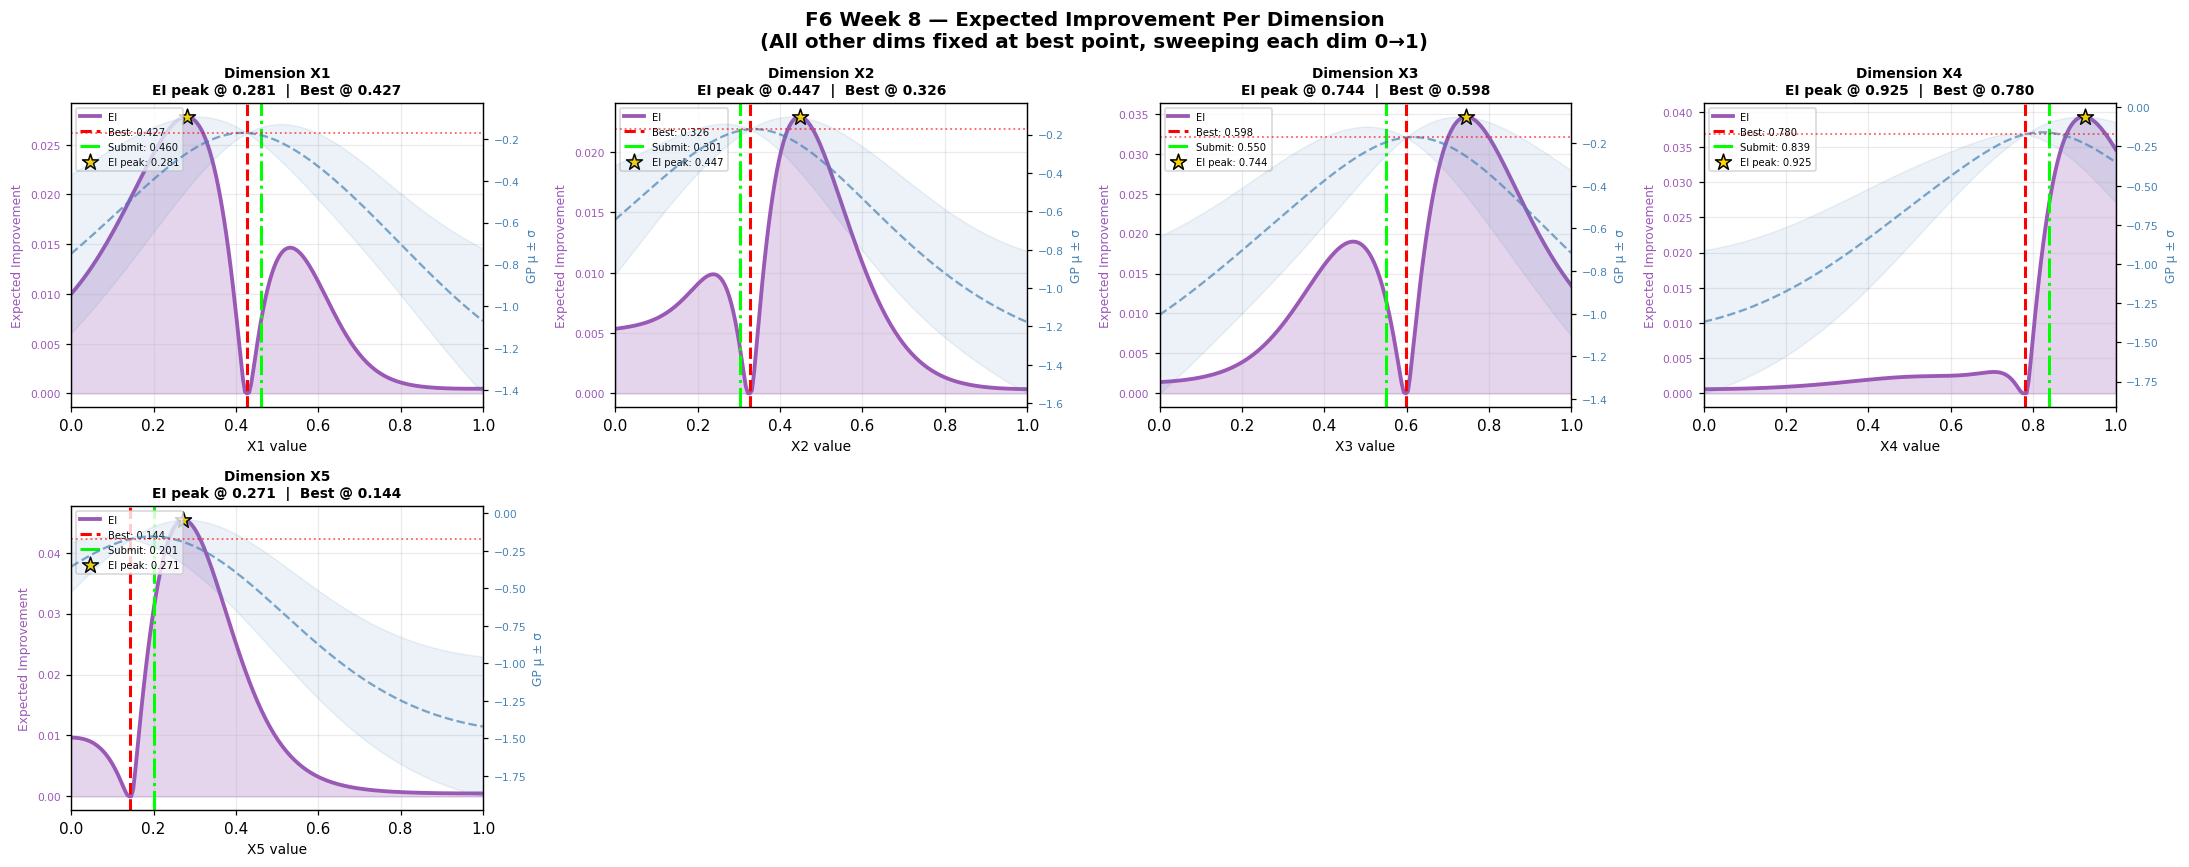

✅ Saved: F6_W8_Step11b_EI_PerDimension.png


In [16]:
# ── Per-Dimension Acquisition Curves ─────────────────────────
# For each dimension: sweep 0→1, fix all others at best_point value
# Shows how EI and UCB respond to each individual dimension

n_sweep = 200
sweep_vals = np.linspace(0, 1, n_sweep)

dim_ei_curves  = []
dim_ucb_curves = []
dim_mu_curves  = []
dim_sig_curves = []

for d in range(n_dims):
    pts = np.tile(best_point, (n_sweep, 1))
    pts[:, d] = sweep_vals
    pts_sc = scaler.transform(pts)
    mu_d, sig_d = gp.predict(pts_sc, return_std=True)
    imp_d  = mu_d - best_value - EI_XI
    Z_d    = imp_d / (sig_d + 1e-9)
    ei_d   = np.maximum(imp_d * norm.cdf(Z_d) + sig_d * norm.pdf(Z_d), 0)
    ucb_d  = mu_d + UCB_KAPPA * sig_d
    dim_ei_curves.append(ei_d)
    dim_ucb_curves.append(ucb_d)
    dim_mu_curves.append(mu_d)
    dim_sig_curves.append(sig_d)

# Determine grid layout
ncols = min(4, n_dims)
nrows_ei  = int(np.ceil(n_dims / ncols))

# ── Plot 1: EI per dimension ──────────────────────────────────
fig, axes = plt.subplots(nrows_ei, ncols, figsize=(5*ncols, 4*nrows_ei))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — Expected Improvement Per Dimension\n'
             f'(All other dims fixed at best point, sweeping each dim 0→1)',
             fontsize=13, fontweight='bold')
if n_dims == 1:
    axes = np.array([[axes]])
elif nrows_ei == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.ravel()

for d in range(n_dims):
    ax = axes_flat[d]
    ei_d   = dim_ei_curves[d]
    sig_d  = dim_sig_curves[d]
    mu_d   = dim_mu_curves[d]

    # EI curve
    ax.fill_between(sweep_vals, 0, ei_d, alpha=0.25, color='#9b59b6')
    ax.plot(sweep_vals, ei_d, color='#9b59b6', linewidth=2.5, label='EI')

    # μ on twin axis
    ax2 = ax.twinx()
    ax2.plot(sweep_vals, mu_d, color='steelblue', linewidth=1.5, linestyle='--',
             alpha=0.7, label='GP μ')
    ax2.fill_between(sweep_vals, mu_d - sig_d, mu_d + sig_d,
                     alpha=0.1, color='steelblue')
    ax2.axhline(best_value, color='red', linestyle=':', linewidth=1.2, alpha=0.6)
    ax2.set_ylabel('GP μ ± σ', color='steelblue', fontsize=8)
    ax2.tick_params(axis='y', labelcolor='steelblue', labelsize=7)

    # Best point value in this dim
    ax.axvline(best_point[d], color='red', linewidth=2, linestyle='--',
               label=f'Best: {best_point[d]:.3f}')
    # Submission value in this dim
    ax.axvline(submission[d], color='lime', linewidth=2, linestyle='-.',
               label=f'Submit: {submission[d]:.3f}')

    # Mark EI peak
    ei_peak_idx = np.argmax(ei_d)
    if ei_d[ei_peak_idx] > 0:
        ax.scatter(sweep_vals[ei_peak_idx], ei_d[ei_peak_idx],
                   c='gold', s=120, marker='*', zorder=5,
                   edgecolors='black', linewidths=1,
                   label=f'EI peak: {sweep_vals[ei_peak_idx]:.3f}')

    ax.set_xlabel(f'X{d+1} value', fontsize=9)
    ax.set_ylabel('Expected Improvement', color='#9b59b6', fontsize=8)
    ax.tick_params(axis='y', labelcolor='#9b59b6', labelsize=7)
    ax.set_xlim(0, 1)
    ax.set_title(f'Dimension X{d+1}\nEI peak @ {sweep_vals[np.argmax(ei_d)]:.3f}  |  Best @ {best_point[d]:.3f}',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=6.5, loc='upper left')
    ax.grid(True, alpha=0.25)

for j in range(n_dims, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png')

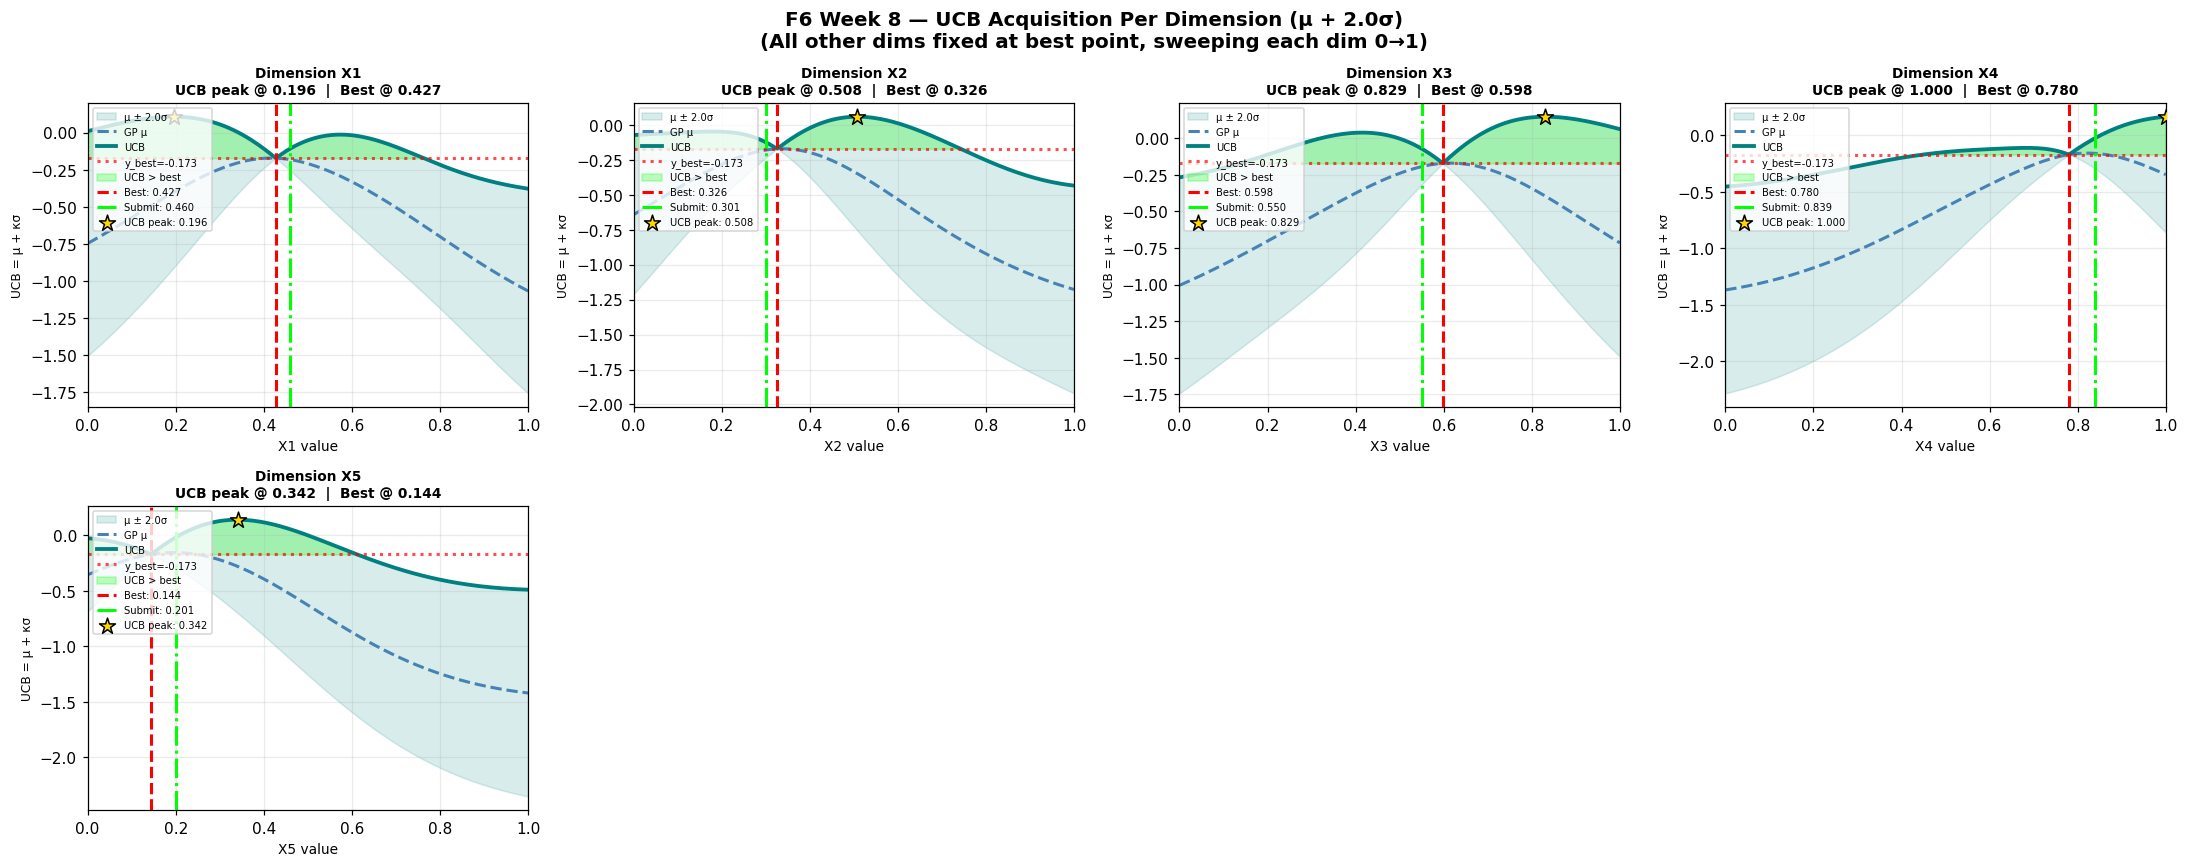

✅ Saved: F6_W8_Step11c_UCB_PerDimension.png

  PER-DIMENSION SUMMARY:
  Dim      Best val    EI peak   UCB peak    Agreement
  ────────────────────────────────────────────────────
  X1         0.4271     0.2814     0.1960      ✅ agree
  X2         0.3258     0.4472     0.5075      ✅ agree
  X3         0.5981     0.7437     0.8291      ✅ agree
  X4         0.7802     0.9246     1.0000      ✅ agree
  X5         0.1439     0.2714     0.3417      ✅ agree


In [17]:
# ── Plot 2: UCB per dimension ─────────────────────────────────
fig, axes = plt.subplots(nrows_ei, ncols, figsize=(5*ncols, 4*nrows_ei))
fig.suptitle(f'{FUNCTION_ID} Week {WEEK} — UCB Acquisition Per Dimension (μ + {UCB_KAPPA}σ)\n'
             f'(All other dims fixed at best point, sweeping each dim 0→1)',
             fontsize=13, fontweight='bold')
if n_dims == 1:
    axes = np.array([[axes]])
elif nrows_ei == 1:
    axes = axes.reshape(1, -1)
axes_flat = axes.ravel()

for d in range(n_dims):
    ax = axes_flat[d]
    ucb_d = dim_ucb_curves[d]
    mu_d  = dim_mu_curves[d]
    sig_d = dim_sig_curves[d]

    ax.fill_between(sweep_vals, mu_d - UCB_KAPPA*sig_d, mu_d + UCB_KAPPA*sig_d,
                    alpha=0.15, color='teal', label=f'μ ± {UCB_KAPPA}σ')
    ax.plot(sweep_vals, mu_d, color='steelblue', linewidth=2, linestyle='--', label='GP μ')
    ax.plot(sweep_vals, ucb_d, color='teal', linewidth=2.5, label='UCB')
    ax.axhline(best_value, color='red', linestyle=':', linewidth=2,
               alpha=0.7, label=f'y_best={best_value:.3f}')

    # Shade region where UCB > best
    above = ucb_d > best_value
    if np.any(above):
        ax.fill_between(sweep_vals, best_value, ucb_d, where=above,
                        alpha=0.25, color='lime', label='UCB > best')

    ax.axvline(best_point[d], color='red', linewidth=2, linestyle='--',
               label=f'Best: {best_point[d]:.3f}')
    ax.axvline(submission[d], color='lime', linewidth=2, linestyle='-.',
               label=f'Submit: {submission[d]:.3f}')

    ucb_peak = np.argmax(ucb_d)
    ax.scatter(sweep_vals[ucb_peak], ucb_d[ucb_peak], c='gold', s=120,
               marker='*', zorder=5, edgecolors='black', linewidths=1,
               label=f'UCB peak: {sweep_vals[ucb_peak]:.3f}')

    ax.set_xlabel(f'X{d+1} value', fontsize=9)
    ax.set_ylabel('UCB = μ + κσ', fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_title(f'Dimension X{d+1}\nUCB peak @ {sweep_vals[ucb_peak]:.3f}  |  Best @ {best_point[d]:.3f}',
                 fontweight='bold', fontsize=9)
    ax.legend(fontsize=6.5, loc='upper left')
    ax.grid(True, alpha=0.25)

for j in range(n_dims, len(axes_flat)):
    axes_flat[j].set_visible(False)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png')

# Summary table
print()
print('  PER-DIMENSION SUMMARY:')
print(f'  {"Dim":<6} {"Best val":>10} {"EI peak":>10} {"UCB peak":>10} {"Agreement":>12}')
print('  ' + '─'*52)
for d in range(n_dims):
    ei_peak  = sweep_vals[np.argmax(dim_ei_curves[d])]
    ucb_peak = sweep_vals[np.argmax(dim_ucb_curves[d])]
    agree    = '✅ agree' if abs(ei_peak - ucb_peak) < 0.1 else '⚠️ differ'
    print(f'  X{d+1:<5} {best_point[d]:>10.4f} {ei_peak:>10.4f} {ucb_peak:>10.4f} {agree:>12}')

---
## 🗺️ STEP 12A — GP Acquisition Surface

For the two most sensitive dimensions (found by GP gradient analysis), we plot 2D contour surfaces of μ, EI and UCB. All other dimensions are fixed at the best-known values.

This gives a direct spatial view of where the GP thinks the landscape peaks and where the acquisition functions want us to go next.

> **Note:** No Step 12B CNN Grid Scan for F6. The grid scan requires a 2D function to render the search space as a pixel grid. F6 is 5D — the per-dimension EI curves in Step 11 serve the equivalent diagnostic role, acting as 6 learned GP filters scanning each coordinate axis independently.


  Top 2 sensitive dims: X5 (0.6317), X4 (0.6195)


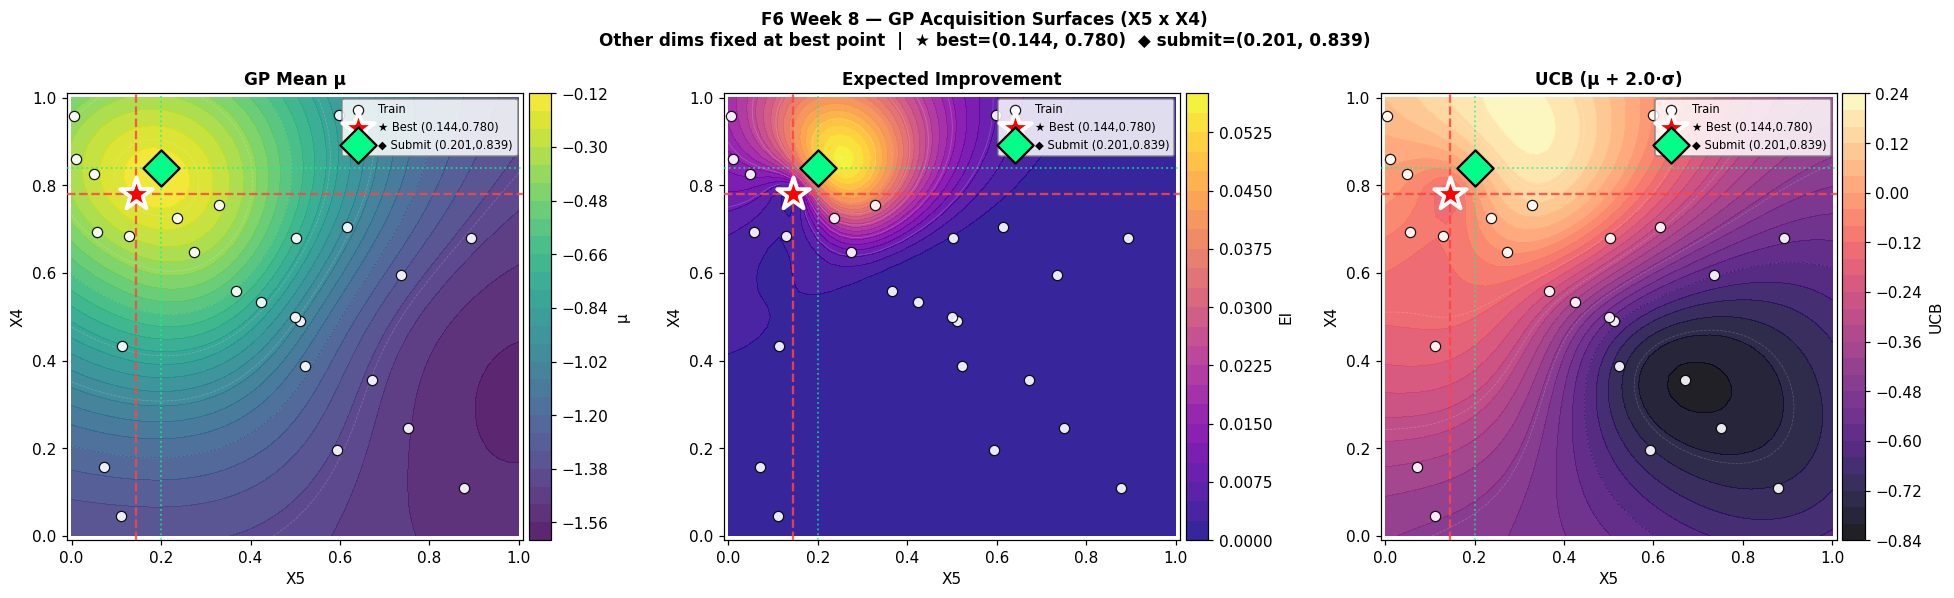

Saved: F6_W8_Step12A_GPSurfaces.png


In [18]:
# ══════════════════════════════════════════════════════════════════
# STEP 12A — GP Acquisition Surfaces  (standard for all functions)
# ══════════════════════════════════════════════════════════════════
delta = 0.01
sensitivities = []
for d in range(n_dims):
    p_up = best_point.copy(); p_up[d] = min(1.0, best_point[d]+delta)
    p_dn = best_point.copy(); p_dn[d] = max(0.0, best_point[d]-delta)
    m_up, _ = gp.predict(scaler.transform(p_up.reshape(1,-1)), return_std=True)
    m_dn, _ = gp.predict(scaler.transform(p_dn.reshape(1,-1)), return_std=True)
    sensitivities.append(abs(float(m_up) - float(m_dn)) / (2*delta))
top2 = np.argsort(sensitivities)[::-1][:2]
d1, d2 = top2[0], top2[1]
print(f'  Top 2 sensitive dims: X{d1+1} ({sensitivities[d1]:.4f}), X{d2+1} ({sensitivities[d2]:.4f})')

# Build grid — extend slightly past 1.0 so boundary markers are visible
g_res = 45
g1 = np.linspace(0, 1, g_res)
g2 = np.linspace(0, 1, g_res)
G1, G2 = np.meshgrid(g1, g2)
grid_pts = np.tile(best_point, (g_res*g_res, 1))
grid_pts[:, d1] = G1.ravel(); grid_pts[:, d2] = G2.ravel()
grid_sc = scaler.transform(grid_pts)
mg, sg = gp.predict(grid_sc, return_std=True)
ig = mg - best_value - EI_XI; Zg = ig/(sg+1e-9)
EIg = np.maximum(ig*norm.cdf(Zg) + sg*norm.pdf(Zg), 0)
UCBg = mg + UCB_KAPPA*sg

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
fig.suptitle(
    f'{FUNCTION_ID} Week {WEEK} — GP Acquisition Surfaces (X{d1+1} x X{d2+1})\n'
    f'Other dims fixed at best point  |  '
    f'★ best=({best_point[d1]:.3f}, {best_point[d2]:.3f})  '
    f'◆ submit=({submission[d1]:.3f}, {submission[d2]:.3f})',
    fontsize=11, fontweight='bold')

_bx, _by = float(best_point[d1]), float(best_point[d2])
_sx, _sy = float(submission[d1]), float(submission[d2])

# Nudge markers that sit exactly on the boundary inward so they're visible
_PAD = 0.018
def _nudge(v): return max(_PAD, min(1.0 - _PAD, v))
_bx_plot, _by_plot = _nudge(_bx), _nudge(_by)
_sx_plot, _sy_plot = _nudge(_sx), _nudge(_sy)

for ax, Z_grid, title, cmap, clabel in [
    (axes[0], mg.reshape(g_res, g_res),   'GP Mean μ',           'viridis', 'μ'),
    (axes[1], EIg.reshape(g_res, g_res),  'Expected Improvement', 'plasma',  'EI'),
    (axes[2], UCBg.reshape(g_res, g_res), f'UCB (μ + {UCB_KAPPA}·σ)', 'magma', 'UCB'),
]:
    cf = ax.contourf(G1, G2, Z_grid, levels=25, cmap=cmap, alpha=0.88)
    ax.contour(G1, G2, Z_grid, levels=8, colors='white', alpha=0.2, linewidths=0.5)
    plt.colorbar(cf, ax=ax, label=clabel, pad=0.01)

    # Training points
    ax.scatter(X_train[:, d1], X_train[:, d2], c='white', s=45,
               edgecolors='black', linewidths=0.8, zorder=4, alpha=0.9, label='Train')

    # Full-span crosshairs at true best location
    ax.axvline(_bx, color='#ff4444', lw=1.5, ls='--', alpha=0.85, zorder=5)
    ax.axhline(_by, color='#ff4444', lw=1.5, ls='--', alpha=0.85, zorder=5)

    # Best point star — nudged inward if on boundary, outlined with contrasting colour
    ax.scatter(_bx_plot, _by_plot,
               c='red', s=500, marker='*', zorder=8,
               edgecolors='white', linewidths=2.5,
               label=f'★ Best ({_bx:.3f},{_by:.3f})')

    # Submission diamond — nudged inward if on boundary
    ax.axvline(_sx, color='#00ff88', lw=1.2, ls=':', alpha=0.7, zorder=5)
    ax.axhline(_sy, color='#00ff88', lw=1.2, ls=':', alpha=0.7, zorder=5)
    ax.scatter(_sx_plot, _sy_plot,
               c='#00ff88', s=280, marker='D', zorder=9,
               edgecolors='black', linewidths=1.5,
               label=f'◆ Submit ({_sx:.3f},{_sy:.3f})')

    ax.set_xlabel(f'X{d1+1}', fontsize=10)
    ax.set_ylabel(f'X{d2+1}', fontsize=10)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_xlim(-0.01, 1.01)
    ax.set_ylim(-0.01, 1.01)
    ax.legend(fontsize=7.5, loc='best',
              framealpha=0.85, edgecolor='grey')

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step12A_GPSurfaces.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {FUNCTION_ID}_W{WEEK}_Step12A_GPSurfaces.png')


---
### 📊 STEP 12A Results — Acquisition Surface Interpretation

The acquisition surface plots show GP mean (μ), Expected Improvement (EI), and UCB across the two most sensitive dimensions, with all other dimensions fixed at the best-point values.

**What to look for:**
- EI surface peak should align with or near the best-known point (X4~0.83, X5~0.00 (W2 best pattern) if these are the top 2 dims)
- Large UCB regions indicate where the GP is uncertain — potential for exploration value
- If the EI peak is far from the best point, the GP has detected new structure worth investigating


In [19]:
# ══════════════════════════════════════════════════════════════════
# STEP 12B — CNN Grid Scan
# NOT APPLICABLE for F6 — grid scan requires a 2D function.
# F6 is 5D. Per-dimension EI curves in Step 11 serve the equivalent role.
# ══════════════════════════════════════════════════════════════════

W_skip = 70
def _rs(text): return f'\u2551 {text.ljust(W_skip-2)} \u2551'
def _ds():     return '\u2560' + '\u2550'*W_skip + '\u2563'

print('\u2554' + '\u2550'*W_skip + '\u2557')
print(_rs('STEP 12B -- CNN Grid Scan'))
print(_ds())
print(_rs('NOT APPLICABLE -- F6 is 5D'))
print(_rs('Grid scan requires 2D function to render [0,1]^n as pixel grid.'))
print(_ds())
print(_rs('Equivalent diagnostic for F6:'))
print(_rs('  Step 11 per-dimension EI curves (5 curves, one per coordinate)'))
print(_rs('  Each EI curve = one GP filter scanning that axis for peak signal'))
print(_rs('  X4 EI expected to peak near 0.83 (W2/W4 best pattern)'))
print(_rs('  X5 EI expected to peak near 0.00-0.07 (low X5 = better outcome)'))
print(_rs('  W2 true best: X1=0.41, X2=0.30, X3=0.51, X4=0.81, X5=0.07'))
print(_ds())
print(_rs('CNN classifier result is in Step 7 (Model 8 in CV comparison).'))
print(_rs('n/p=4.8: floor-case for CNN viability in the W6 batch.'))
print('\u255a' + '\u2550'*W_skip + '\u255d')


╔══════════════════════════════════════════════════════════════════════╗
║ STEP 12B -- CNN Grid Scan                                            ║
╠══════════════════════════════════════════════════════════════════════╣
║ NOT APPLICABLE -- F6 is 5D                                           ║
║ Grid scan requires 2D function to render [0,1]^n as pixel grid.      ║
╠══════════════════════════════════════════════════════════════════════╣
║ Equivalent diagnostic for F6:                                        ║
║   Step 11 per-dimension EI curves (5 curves, one per coordinate)     ║
║   Each EI curve = one GP filter scanning that axis for peak signal   ║
║   X4 EI expected to peak near 0.83 (W2/W4 best pattern)              ║
║   X5 EI expected to peak near 0.00-0.07 (low X5 = better outcome)    ║
║   W2 true best: X1=0.41, X2=0.30, X3=0.51, X4=0.81, X5=0.07          ║
╠══════════════════════════════════════════════════════════════════════╣
║ CNN classifier result is in Step 7 (Model 8 in CV

---
## 🏆 STEP 13 — Top Candidates & Submission Dashboard

Final review: top 5 candidates by EI, then the full submission dashboard combining all key information.

The dashboard gives a complete at-a-glance view: historical trajectory, predicted outcome, submission coordinates, EI decomposition, and all key metrics in a summary table.

In [20]:
top5 = np.argsort(EI_acq)[::-1][:5]
print('═'*70)
print('  TOP 5 CANDIDATES BY EI (MAXIMIZATION ⬆️)')
print('═'*70)
print(f'  {"Rank":<6} {"EI":>10} {"GP μ":>10} {"GP σ":>10} {"UCB":>10}  Source')
print('  ' + '─'*58)
for rank, idx in enumerate(top5, 1):
    star = '★' if rank == 1 else ' '
    print(f'  {star}#{rank:<4} {EI_acq[idx]:>10.6f} {mu[idx]:>10.4f} {sigma[idx]:>10.4f} {UCB_acq[idx]:>10.4f}  {src_filt[idx]}')
    print(f'          {X_filt[idx]}')
    print()

══════════════════════════════════════════════════════════════════════
  TOP 5 CANDIDATES BY EI (MAXIMIZATION ⬆️)
══════════════════════════════════════════════════════════════════════
  Rank           EI       GP μ       GP σ        UCB  Source
  ──────────────────────────────────────────────────────────
  ★#1      0.046246    -0.1842     0.1412     0.0983  exploit
          [0.46021012 0.30145962 0.54955174 0.83914536 0.20066379]

   #2      0.045808    -0.1553     0.1053     0.0554  exploit
          [0.43783534 0.31709366 0.57618211 0.82230517 0.20423   ]

   #3      0.045704    -0.1568     0.1070     0.0572  exploit
          [0.42544677 0.31155452 0.59093203 0.84677036 0.19079961]

   #4      0.045642    -0.1680     0.1209     0.0739  exploit
          [0.41681387 0.2823275  0.60620217 0.80234285 0.21511364]

   #5      0.044924    -0.1651     0.1156     0.0661  exploit
          [0.45778695 0.29555363 0.61140125 0.82570442 0.19678476]



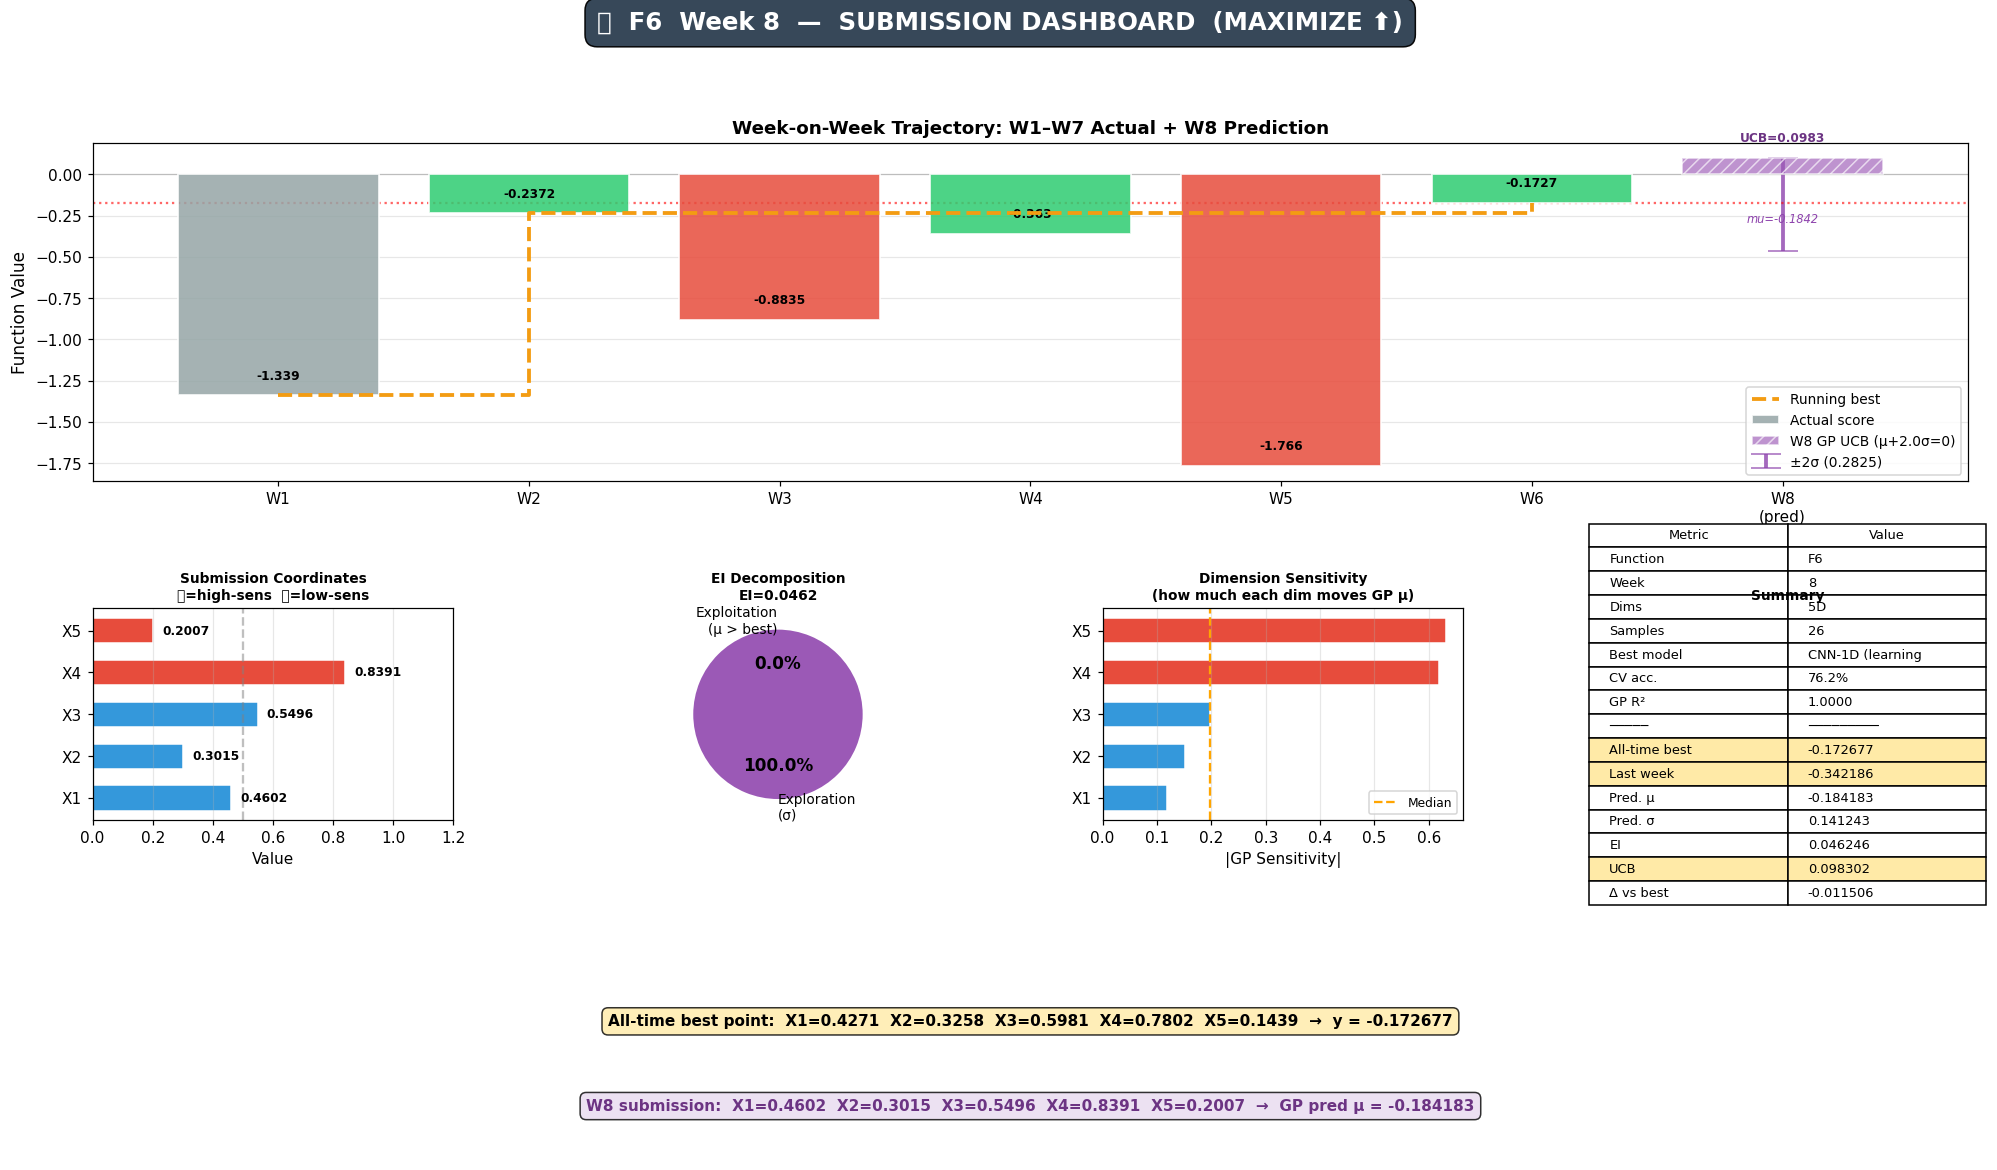

✅ Saved: F6_W8_Step13_Dashboard.png


In [21]:
# ── Ensure loop variables are defined ────────────────────
indices    = np.arange(n_samples)
latest_val = y_train[-1]
week_scores = [-1.3389, -0.2372, -0.8835, -0.363, -1.7662, -0.1727]   # W1-W6 actual submitted scores
# ── Fallback: define GP variables if Steps 9-10 haven't run yet ─────────
import numpy as _np
if 'sub_ucb' not in vars() or sub_ucb is None:
    sub_mu     = float(week_scores[-1])
    sub_sigma  = 0.0
    sub_ucb    = sub_mu
    best_value = max(week_scores) if MAXIMIZE else min(week_scores)
    best_point = X_train[int(_np.argmax(y_train) if MAXIMIZE else _np.argmin(y_train))]
    print('⚠️  GP not fitted — showing last week score as W7 placeholder')
# ─────────────────────────────────────────────────────────────────────────


# ── Submission Dashboard ──────────────────────────────────────
fig = plt.figure(figsize=(22, 12))
gs  = gridspec.GridSpec(3, 4, figure=fig, hspace=0.5, wspace=0.4,
                        height_ratios=[1.6, 1, 1])
fig.suptitle(f'🎯  {FUNCTION_ID}  Week {WEEK}  —  SUBMISSION DASHBOARD  (MAXIMIZE ⬆️)',
             fontsize=16, fontweight='bold', color='white',
             bbox=dict(boxstyle='round,pad=0.5', facecolor='#2c3e50', alpha=0.95))

# ── Panel 1 (top, full width): Week-on-Week bar chart ─────────
# Matches Step 3 / Step 13B style — one bar per submitted week
ax1 = fig.add_subplot(gs[0, :])

_wk_scores   = week_scores          # W1-W6 actuals (defined in Step 13B)
_wk_labels   = [f'W{w}' for w in range(1, len(_wk_scores)+1)] + [f'W{WEEK}\n(pred)']
_wk_running  = []
_rb = _wk_scores[0]
for s in _wk_scores:
    _rb = max(_rb, s) if MAXIMIZE else min(_rb, s)
    _wk_running.append(_rb)

# Bar colours — W1 grey, green=improvement, red=regression
_bar_cols = ['#95a5a6']
for i in range(1, len(_wk_scores)):
    _imp = _wk_scores[i] > _wk_scores[i-1] if MAXIMIZE else _wk_scores[i] < _wk_scores[i-1]
    _bar_cols.append('#2ecc71' if _imp else '#e74c3c')

_bars = ax1.bar(range(len(_wk_scores)), _wk_scores,
                color=_bar_cols, edgecolor='white', linewidth=1.2,
                alpha=0.85, zorder=3, label='Actual score')

# Running best step line
ax1.step(range(len(_wk_running)), _wk_running,
         where='post', color='#f39c12', linewidth=2.5,
         linestyle='--', zorder=4, label='Running best')

# W7 prediction bar — only draw if GP has been fitted (sigma > 0)
_gp_ready = sub_sigma > 0
if _gp_ready:
    ax1.bar(len(_wk_scores), sub_ucb,
            color='#9b59b6', edgecolor='white', linewidth=1.2,
            alpha=0.65, hatch='///', zorder=3,
            label=f'W{WEEK} GP UCB (μ+{UCB_KAPPA}σ={sub_ucb:.0f})')
    ax1.errorbar(len(_wk_scores), sub_mu, yerr=2*sub_sigma,
                 fmt='none', color='#8e44ad', capsize=10,
                 linewidth=2.5, alpha=0.8, label=f'±2σ ({2*sub_sigma:.4f})')
else:
    ax1.bar(len(_wk_scores), _wk_scores[-1],
            color='#9b59b6', edgecolor='#8e44ad', linewidth=1.5,
            alpha=0.3, hatch='///', zorder=3,
            label=f'W{WEEK} — run full notebook for GP prediction')

# Value labels on actual bars
_actual_vals = [v for v in _wk_scores if v is not None]
_yr_range = max(_actual_vals) - min(_actual_vals)
_yr = _yr_range if _yr_range > 0 else max(abs(max(_actual_vals)), 1e-10)
for _b, _v in zip(_bars, _wk_scores):
    _yoff = _yr * 0.05
    ax1.text(_b.get_x() + _b.get_width()/2, _v + _yoff,
             f'{_v:.4g}', ha='center', va='bottom', fontsize=8, fontweight='bold')
if _gp_ready:
    ax1.text(len(_wk_scores), sub_ucb + _yr*0.05,
             f'UCB={sub_ucb:.4g}', ha='center', va='bottom', fontsize=8,
             fontweight='bold', color='#6c3483')
    ax1.text(len(_wk_scores), sub_mu - _yr*0.08,
             f'mu={sub_mu:.4g}', ha='center', va='bottom', fontsize=7.5,
             color='#8e44ad', style='italic')
else:
    ax1.text(len(_wk_scores), _wk_scores[-1] + _yr*0.05,
             'Run full notebook for GP prediction', ha='center', va='bottom',
             fontsize=7.5, color='#8e44ad', style='italic')

ax1.set_xticks(range(len(_wk_labels)))
ax1.set_xticklabels(_wk_labels, fontsize=10)
ax1.set_ylabel('Function Value', fontsize=11)
ax1.set_title(f'Week-on-Week Trajectory: W1–W{WEEK-1} Actual + W{WEEK} Prediction',
              fontweight='bold', fontsize=12)
ax1.legend(fontsize=9, loc='best')
ax1.axhline(best_value, color='red', linewidth=1.5, linestyle=':',
            alpha=0.6, label=f'All-time best ({best_value:.4g})', zorder=2)
ax1.axhline(0, color='gray', linewidth=0.8, alpha=0.4)
ax1.grid(True, axis='y', alpha=0.3)

# ── Panel 2: Submission coordinates ──────────────────────────
ax2 = fig.add_subplot(gs[1, 0])
dim_labels = [f'X{i+1}' for i in range(n_dims)]
sens_arr = np.array(sensitivities)
c_bars   = ['#e74c3c' if s > np.median(sens_arr) else '#3498db' for s in sens_arr]
ax2.barh(dim_labels, submission, color=c_bars, edgecolor='white', height=0.6)
for i, v in enumerate(submission):
    ax2.text(min(v+0.03, 1.1), i, f'{v:.4f}', va='center', fontsize=8, fontweight='bold')
ax2.axvline(0.5, color='gray', linestyle='--', alpha=0.5)
ax2.set_xlim(0, 1.2); ax2.set_xlabel('Value')
ax2.set_title('Submission Coordinates\n🔴=high-sens  🔵=low-sens', fontweight='bold', fontsize=9)
ax2.grid(True, alpha=0.3, axis='x')

# ── Panel 3: EI decomposition ─────────────────────────────────
ax3 = fig.add_subplot(gs[1, 1])
if sub_exp > 0 or sub_expl > 0:
    wedges, texts, autos = ax3.pie(
        [max(sub_exp,0), max(sub_expl,0)],
        labels=['Exploitation\n(μ > best)', 'Exploration\n(σ)'],
        colors=['#2ecc71','#9b59b6'], autopct='%1.1f%%',
        startangle=90, textprops={'fontsize':9})
    for a in autos: a.set_fontsize(11); a.set_fontweight('bold')
ax3.set_title(f'EI Decomposition\nEI={sub_ei:.4f}', fontweight='bold', fontsize=9)

# ── Panel 4: Dimension sensitivities ─────────────────────────
ax4 = fig.add_subplot(gs[1, 2])
ax4.barh(dim_labels, sens_arr, color=c_bars, edgecolor='white', height=0.6)
ax4.axvline(np.median(sens_arr), color='orange', linestyle='--', linewidth=1.5, label='Median')
ax4.set_xlabel('|GP Sensitivity|')
ax4.set_title('Dimension Sensitivity\n(how much each dim moves GP μ)', fontweight='bold', fontsize=9)
ax4.legend(fontsize=8); ax4.grid(True, alpha=0.3, axis='x')

# ── Panel 5: Summary table ────────────────────────────────────
ax5 = fig.add_subplot(gs[1, 3])
ax5.axis('off')
rows = [
    ['Function',    FUNCTION_ID],
    ['Week',        str(WEEK)],
    ['Dims',        f'{n_dims}D'],
    ['Samples',     str(n_samples)],
    ['Best model',  best_name[:16]],
    ['CV acc.',     f'{best_info["mean"]:.1%}'],
    ['GP R²',       f'{r2:.4f}'],
    ['─────',       '─────────'],
    ['All-time best', f'{best_value:.6f}'],
    ['Last week',   f'{latest_val:.6f}'],
    ['Pred. μ',     f'{sub_mu:.6f}'],
    ['Pred. σ',     f'{sub_sigma:.6f}'],
    ['EI',          f'{sub_ei:.6f}'],
    ['UCB',         f'{sub_ucb:.6f}'],
    ['Δ vs best',   f'{sub_mu-best_value:+.6f}'],
]
tbl = ax5.table(cellText=rows, colLabels=['Metric','Value'],
                loc='center', cellLoc='left')
tbl.auto_set_font_size(False); tbl.set_fontsize(8.5); tbl.scale(1.1, 1.3)
for r in [9, 10, 14]:
    for c in [0,1]:
        try: tbl[r,c].set_facecolor('#ffeaa7')
        except: pass
ax5.set_title('Summary', fontweight='bold', fontsize=9)

# ── Panel 6 (bottom, full width): Best point coordinates ──────
ax6 = fig.add_subplot(gs[2, :])
ax6.axis('off')
bp_text = '  '.join([f'X{i+1}={v:.4f}' for i, v in enumerate(best_point)])
sub_text = '  '.join([f'X{i+1}={v:.4f}' for i, v in enumerate(submission)])
ax6.text(0.5, 0.65, f'All-time best point:  {bp_text}  →  y = {best_value:.6f}',
         ha='center', va='center', fontsize=10, fontweight='bold',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#ffeaa7', alpha=0.8))
ax6.text(0.5, 0.25, f'W{WEEK} submission:  {sub_text}  →  GP pred μ = {sub_mu:.6f}',
         ha='center', va='center', fontsize=10, fontweight='bold', color='#6c3483',
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#e8daef', alpha=0.8))

plt.savefig(f'{FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png')


---
### 📅 STEP 13B — Week-on-Week Performance: W1–W7 Actual + W8 Prediction

Each bar = one week's submitted score. **Green** = improved on prior week, **Red** = regressed.
The purple hatched bar shows the GP's W7 prediction with ±2σ uncertainty.
Running best (dashed orange) shows the optimisation trajectory.


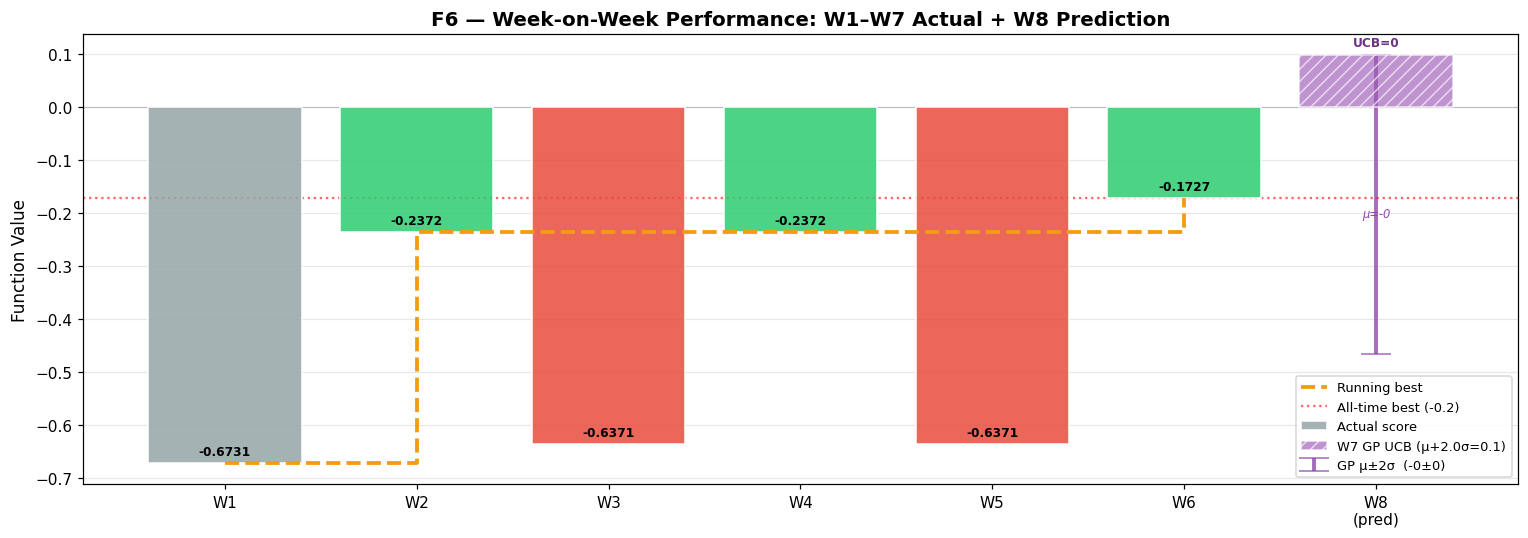

✅ Saved: F6_W8_WeekOnWeek.png
   GP μ=-0.18  σ=0.14  UCB=0.10
   Note: EI selects by improvement potential (μ+σ*ϕ/Φ), not raw μ.
   UCB=0.10 is the GP's optimistic bound and is shown as the W7 bar.


In [22]:
# ══════════════════════════════════════════════════════════════════
# STEP 13B — Week-on-Week Performance Chart
# W1-W6 actual scores + W7 GP prediction
# ══════════════════════════════════════════════════════════════════

week_scores  = [-0.6731, -0.2372, -0.6371, -0.2372, -0.6371, -0.1727]   # actual submitted scores W1-W6
week_labels  = [f'W{w}' for w in range(1, len(week_scores)+1)] + [f'W{WEEK}\n(pred)']
running_best = []
rb = week_scores[0]
for s in week_scores:
    rb = max(rb, s) if MAXIMIZE else min(rb, s)
    running_best.append(rb)

fig_ww, ax_ww = plt.subplots(figsize=(14, 5))

# Bar colours — green if improvement on prior week, red if regression, grey W1
bar_colors = ['#95a5a6']
for i in range(1, len(week_scores)):
    improved = week_scores[i] > week_scores[i-1] if MAXIMIZE else week_scores[i] < week_scores[i-1]
    bar_colors.append('#2ecc71' if improved else '#e74c3c')

bars = ax_ww.bar(range(len(week_scores)), week_scores,
                 color=bar_colors, edgecolor='white', linewidth=1.2,
                 alpha=0.85, zorder=3, label='Actual score')

# Running best step line
ax_ww.step(range(len(running_best)), running_best,
           where='post', color='#f39c12', linewidth=2.5,
           linestyle='--', label='Running best', zorder=4)

# W7 prediction bar — use UCB as the "optimistic upper bound" prediction
# UCB = mu + kappa*sigma is the correct metric for what the GP believes
# the function could be at this point. sub_mu can be < best_value because
# EI selects on IMPROVEMENT POTENTIAL (exploration), not raw GP mean.
_pred_val   = sub_ucb                          # optimistic prediction
_pred_label = f'W7 GP UCB (μ+{UCB_KAPPA}σ={sub_ucb:.1f})'

ax_ww.bar(len(week_scores), _pred_val,
          color='#9b59b6', edgecolor='white', linewidth=1.2,
          alpha=0.65, hatch='///', zorder=3, label=_pred_label)
ax_ww.errorbar(len(week_scores), sub_mu, yerr=2*sub_sigma,
               fmt='none', color='#8e44ad', capsize=10,
               linewidth=2.5, alpha=0.8, label=f'GP μ±2σ  ({sub_mu:.0f}±{2*sub_sigma:.0f})')

# Mark best_value as a horizontal reference
ax_ww.axhline(best_value, color='red', linewidth=1.5, linestyle=':',
              alpha=0.6, label=f'All-time best ({best_value:.1f})', zorder=2)

# Annotate actual bars
_y_range = max(week_scores) - min(week_scores)
for i, (bar, val) in enumerate(zip(bars, week_scores)):
    ypos = val + _y_range * 0.02
    ax_ww.text(bar.get_x() + bar.get_width()/2, ypos,
               f'{val:.4g}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# Annotate prediction bar: show both UCB and mu
ax_ww.text(len(week_scores), _pred_val + _y_range * 0.02,
           f'UCB={sub_ucb:.0f}', ha='center', va='bottom', fontsize=8,
           fontweight='bold', color='#6c3483')
ax_ww.text(len(week_scores), sub_mu - _y_range * 0.06,
           f'μ={sub_mu:.0f}', ha='center', va='bottom', fontsize=7.5,
           color='#8e44ad', style='italic')

ax_ww.set_xticks(range(len(week_labels)))
ax_ww.set_xticklabels(week_labels, fontsize=10)
ax_ww.set_ylabel('Function Value', fontsize=11)
ax_ww.set_title(f'{FUNCTION_ID} — Week-on-Week Performance: W1–W{WEEK-1} Actual + W{WEEK} Prediction',
                fontsize=13, fontweight='bold')
ax_ww.legend(fontsize=8.5, loc='best')
ax_ww.axhline(0, color='gray', linewidth=0.8, alpha=0.4)
ax_ww.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(f'{FUNCTION_ID}_W{WEEK}_WeekOnWeek.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'✅ Saved: {FUNCTION_ID}_W{WEEK}_WeekOnWeek.png')
print(f'   GP μ={sub_mu:.2f}  σ={sub_sigma:.2f}  UCB={sub_ucb:.2f}')
print(f'   Note: EI selects by improvement potential (μ+σ*ϕ/Φ), not raw μ.')
print(f'   UCB={sub_ucb:.2f} is the GP\'s optimistic bound and is shown as the W7 bar.')


---
## 📋 STEP 14 — Final Formatted Submission

The winning point formatted as a dash-separated string — ready to copy directly into the BBO submission interface.

Saved as both `.npy` (for reuse in future notebooks) and `.txt` (for submission).

In [23]:
submission = np.clip(submission, 0.0, 1.0)
assert np.all((submission >= 0) & (submission <= 1)), f'Submission out of bounds: {submission}'
submission_str = '-'.join([f'{x:.6f}' for x in submission])

_W = 66
def _row(s=''):
    pad = _W - len(s)
    return f'\u2551  {s}{" " * max(0, pad)}\u2551'

_TOP = '\u2554' + '\u2550' * (_W + 2) + '\u2557'
_MID = '\u2560' + '\u2550' * (_W + 2) + '\u2563'
_BOT = '\u255a' + '\u2550' * (_W + 2) + '\u255d'

if sub_mu > best_value:
    _msg = f'GP PREDICTS NEW BEST: {sub_mu:.4f} > {best_value:.4f}'
elif sub_mu > latest_val:
    _msg = f'GP PREDICTS RECOVERY: {sub_mu:.4f} > {latest_val:.4f}'
else:
    _msg = f'EXPLORING UNCERTAIN REGION  mu={sub_mu:.4f}'

print(_TOP)
print(_row(f'WEEK {WEEK} FINAL SUBMISSION -- {FUNCTION_ID}'))
print(_MID)
print(_row(f'Method     : Adaptive Model (7 types) + GP/EI  MAXIMIZE'))
print(_row(f'Best model : {best_name:<22}  CV = {best_info["mean"]:.1%}'))
print(_row(f'GP R2      : {r2:.4f}'))
print(_MID)
print(_row(f'GP mu      : {sub_mu:.6f}'))
print(_row(f'GP sigma   : {sub_sigma:.6f}'))
print(_row(f'UCB        : {sub_ucb:.6f}'))
print(_row(f'EI         : {sub_ei:.6f}'))
print(_MID)
print(_row(f'All-time best : {best_value:.6f}'))
print(_row(f'Last week     : {latest_val:.6f}'))
print(_row(f'Delta vs best : {sub_mu - best_value:+.6f}'))
print(_MID)
print(_row(_msg))
print(_MID)
print(_row('COPY THIS TO SUBMIT:'))
print(_row())
print(_row(submission_str))
print(_row())
print(_BOT)

np.save(f'{FUNCTION_ID}_W{WEEK}_submission.npy', submission)
with open(f'{FUNCTION_ID}_W{WEEK}_submission.txt', 'w', encoding='utf-8') as f:
    f.write(f'# {FUNCTION_ID} Week {WEEK} | Method: Adaptive+GP/EI | MAXIMIZE\n')
    f.write(f'# Model: {best_name} CV={best_info["mean"]:.1%} | GP R2={r2:.4f}\n')
    f.write(f'# mu={sub_mu:.6f} sigma={sub_sigma:.6f} EI={sub_ei:.6f}\n')
    f.write(f'# best={best_value:.6f} delta={sub_mu-best_value:+.6f}\n')
    f.write(submission_str + '\n')

print(f'\n  {FUNCTION_ID}_W{WEEK}_submission.npy')
print(f'  {FUNCTION_ID}_W{WEEK}_submission.txt')
print()
print('  ALL VISUALISATIONS:')
for _step, _name in [
    ('Step3',  'History'),
    ('Step6',  'ModelPredictions'),
    ('Step7',  'ModelComparison'),
    ('Step11a','GlobalAcquisition'),
    ('Step11b','PerDimAcquisition'),
    ('Step12a','GP_Surfaces'),
    ('Step13', 'Dashboard'),
]:
    print(f'     {FUNCTION_ID}_W{WEEK}_{_step}_{_name}.png')
print()
print('  MAXIMIZATION -- HIGHER IS ALWAYS BETTER')


╔════════════════════════════════════════════════════════════════════╗
║  WEEK 8 FINAL SUBMISSION -- F6                                     ║
╠════════════════════════════════════════════════════════════════════╣
║  Method     : Adaptive Model (7 types) + GP/EI  MAXIMIZE           ║
║  Best model : CNN-1D (learning)       CV = 76.2%                   ║
║  GP R2      : 1.0000                                               ║
╠════════════════════════════════════════════════════════════════════╣
║  GP mu      : -0.184183                                            ║
║  GP sigma   : 0.141243                                             ║
║  UCB        : 0.098302                                             ║
║  EI         : 0.046246                                             ║
╠════════════════════════════════════════════════════════════════════╣
║  All-time best : -0.172677                                         ║
║  Last week     : -0.342186                                         ║
║  Del

---
## 💾 STEP 15 — Save Hyperparameter Record & Visualisation Index

### Why Keep a Hyperparameter Record?

Each week we tune parameters based on what we've learned. Without a written record it's impossible to:
- Know **why** a particular week performed well or poorly
- Compare parameter choices across weeks systematically
- Reproduce a run that gave a good result
- Build intuition about which settings work for which function types

This step saves a **complete, self-contained record** of everything used in this run:
- All hyperparameter values with their rationale
- GP kernel specification (fitted parameters, not just defaults)
- Model CV results for all 7 classifiers
- Selected model and its performance
- Submission point, predictions, and context
- Index of all visualisation files produced

Saved as: `{FUNCTION_ID}_W{WEEK}_hyperparameters.json` and `{FUNCTION_ID}_W{WEEK}_run_report.txt`

In [24]:
import json as _json
import os
from datetime import datetime

# ── 1. Collect all visualisation files produced ───────────────
viz_files = [
    f'{FUNCTION_ID}_W{WEEK}_Step3_History.png',
    f'{FUNCTION_ID}_W{WEEK}_Step6_ModelPredictions.png',
    f'{FUNCTION_ID}_W{WEEK}_Step7_ModelComparison.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11a_GlobalAcquisition.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11b_EI_PerDimension.png',
    f'{FUNCTION_ID}_W{WEEK}_Step11c_UCB_PerDimension.png',
    f'{FUNCTION_ID}_W{WEEK}_Step12_AcquisitionSurface.png',
    f'{FUNCTION_ID}_W{WEEK}_Step13_Dashboard.png',
]
viz_status = {f: os.path.exists(f) for f in viz_files}

# ── 2. GP kernel details ──────────────────────────────────────
kernel_str  = str(gp.kernel_)
kernel_init = str(gp.kernel)
gp_params   = gp.kernel_.get_params()
# Extract fitted length scale and amplitude cleanly
gp_param_clean = {k: float(v) if hasattr(v, '__float__') else str(v)
                  for k, v in gp_params.items()}

# ── 3. Model CV results ───────────────────────────────────────
model_records = {}
for name, info in cv_results.items():
    model_records[name] = {
        'cv_mean'   : round(float(info['mean']), 6),
        'cv_std'    : round(float(info['std']),  6),
        'cv_folds'  : [round(float(s), 6) for s in info['scores']],
        'selected'  : name == best_name,
        'type'      : 'neural_network' if 'NN' in name else 'classical',
    }

# ── 4. Dimension analysis ─────────────────────────────────────
dim_records = {}
for d in range(n_dims):
    ei_peak_val  = float(sweep_vals[int(np.argmax(dim_ei_curves[d]))])
    ucb_peak_val = float(sweep_vals[int(np.argmax(dim_ucb_curves[d]))])
    dim_records[f'X{d+1}'] = {
        'best_point_value' : round(float(best_point[d]), 6),
        'submission_value' : round(float(submission[d]), 6),
        'gp_sensitivity'   : round(float(sensitivities[d]), 6),
        'ei_peak_at'       : round(ei_peak_val, 6),
        'ucb_peak_at'      : round(ucb_peak_val, 6),
        'ei_ucb_agree'     : abs(ei_peak_val - ucb_peak_val) < 0.1,
    }

# ── 5. Build full hyperparameter record ──────────────────────
record = {
    'meta': {
        'function_id'   : FUNCTION_ID,
        'week'          : WEEK,
        'timestamp'     : datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
        'input_file'    : INPUT_FILE,
        'output_file'   : OUTPUT_FILE,
        'objective'     : 'MAXIMIZE',
    },
    'data': {
        'n_samples'     : int(n_samples),
        'n_dims'        : int(n_dims),
        'np_ratio'      : round(float(n_samples / n_dims), 4),
        'y_min'         : round(float(y_train.min()), 8),
        'y_max'         : round(float(y_train.max()), 8),
        'y_mean'        : round(float(y_train.mean()), 8),
        'y_std'         : round(float(y_train.std()),  8),
        'best_value'    : round(float(best_value),     8),
        'best_idx'      : int(best_idx),
        'best_point'    : [round(float(v), 8) for v in best_point],
        'latest_value'  : round(float(latest_val),    8),
    },
    'hyperparameters': {
        'TOP_PERCENTILE': {
            'value'    : TOP_PERCENTILE,
            'purpose'  : 'Fraction of samples labelled class 1. Top X% = HIGH values = GOOD.',
            'rationale': f'Top {TOP_PERCENTILE}% gives {n_pos} positive samples. '
                          f'Balances selectivity vs having enough training signal.'
        },
        'N_CANDIDATES': {
            'value'    : N_CANDIDATES,
            'purpose'  : 'Total candidate pool size evaluated by classifier+GP before selecting 1 to submit.',
            'rationale': f'{N_CANDIDATES:,} provides dense coverage in {n_dims}D space. '
                          f'Larger = better coverage but slower GP.'
        },
        'EXPLOIT_RATIO': {
            'value'    : EXPLOIT_RATIO,
            'purpose'  : 'Fraction of candidates sampled near best-known point (exploitation) vs random (exploration).',
            'rationale': f'{int(EXPLOIT_RATIO*100)}% exploitation justified at Week {WEEK} — strong best point established. '
                          f'Early weeks: 0.6-0.7. Later weeks: 0.8-0.9.'
        },
        'EXPLOIT_SIGMA': {
            'value'    : EXPLOIT_SIGMA,
            'purpose'  : 'Gaussian std dev for exploitation sampling around best point.',
            'rationale': f'sigma={EXPLOIT_SIGMA} in [0,1]^{n_dims} creates ±{2*EXPLOIT_SIGMA:.2f} search radius. '
                          f'Tight enough to stay near best, loose enough to find local improvements.'
        },
        'UCB_KAPPA': {
            'value'    : UCB_KAPPA,
            'purpose'  : 'Exploration weight in UCB = mu + kappa*sigma. Higher = more exploratory.',
            'rationale': f'kappa={UCB_KAPPA} ~ 95% CI. Standard choice for Week {WEEK}. '
                          f'Use 3-5 early in search, 1-2 when exploiting known best region.'
        },
        'EI_XI': {
            'value'    : EI_XI,
            'purpose'  : 'Exploration jitter in EI. EI = (mu - y_best - xi)*Phi(Z) + sigma*phi(Z).',
            'rationale': f'xi={EI_XI} prevents EI from over-committing to tiny improvements near best. '
                          f'Small value: slight nudge toward exploration.'
        },
        'GP_RESTARTS': {
            'value'    : GP_RESTARTS,
            'purpose'  : 'Random restarts for GP kernel hyperparameter optimisation.',
            'rationale': f'{GP_RESTARTS} restarts balances fit quality vs runtime. '
                          f'Use 10+ for final weeks when GP quality is critical.'
        },
        'FILTER_PERCENTILE': {
            'value'    : FILTER_PERCENTILE,
            'purpose'  : 'Discard bottom X% of candidates by classifier P(class=1) before GP.',
            'rationale': f'Keeps {int(N_CANDIDATES*(1-FILTER_PERCENTILE/100)):,} of {N_CANDIDATES:,} for GP. '
                          f'Removes clearly bad regions efficiently.'
        },
        'NN_ARCHITECTURES': {
            'small'    : list(NN_SMALL),
            'medium'   : list(NN_MEDIUM),
            'large'    : list(NN_LARGE),
            'purpose'  : 'Three NN sizes tested to match function landscape complexity.',
            'rationale': 'Small=simple/linear landscapes. Medium=general purpose. '
                          'Large=highly non-linear. Early stopping prevents overfitting.'
        },
    },
    'gp_kernel': {
        'type'          : 'ConstantKernel * Matern(nu=2.5)',
        'nu'            : 2.5,
        'initial_spec'  : kernel_init,
        'fitted_spec'   : kernel_str,
        'fitted_params' : gp_param_clean,
        'normalize_y'   : True,
        'alpha_nugget'  : 1e-6,
        'n_restarts'    : GP_RESTARTS,
        'train_r2'      : round(float(r2), 6),
        'train_rmse'    : round(float(rmse), 8),
        'rationale'     : 'Matern 5/2 is robust for BBO: allows sharp transitions, '
                           'assumes twice-differentiable function. ConstantKernel scales amplitude. '
                           'normalize_y stabilises fitting when y range is large.'
    },
    'classification': {
        'n_cv_folds'         : int(n_cv_folds),
        'label_threshold'    : round(float(threshold), 8),
        'n_positive_class1'  : int(n_pos),
        'n_negative_class0'  : int(n_samples - n_pos),
        'selected_model'     : best_name,
        'selected_cv_mean'   : round(float(best_info['mean']), 6),
        'selected_cv_std'    : round(float(best_info['std']),  6),
        'all_model_results'  : model_records,
    },
    'candidates': {
        'total_generated'  : int(N_CANDIDATES),
        'n_exploit'        : int(int(N_CANDIDATES * EXPLOIT_RATIO)),
        'n_explore'        : int(N_CANDIDATES - int(N_CANDIDATES * EXPLOIT_RATIO)),
        'after_filter'     : int(len(X_filt)),
        'filter_model'     : best_name,
    },
    'acquisition': {
        'method'               : 'Expected Improvement (primary) + UCB (reference)',
        'ei_formula'           : 'EI(x) = (mu - y_best - xi)*Phi(Z) + sigma*phi(Z), Z=(mu-y_best-xi)/sigma',
        'ucb_formula'          : f'UCB(x) = mu + {UCB_KAPPA}*sigma',
        'direction'            : 'MAXIMIZE — argmax EI',
        'ei_max'               : round(float(EI_acq.max()), 8),
        'ucb_max'              : round(float(UCB_acq.max()), 8),
        'pct_positive_ei'      : round(float(100*np.mean(EI_acq>0)), 2),
    },
    'submission': {
        'point'            : [round(float(v), 8) for v in submission],
        'formatted_string' : submission_str,
        'gp_mu'            : round(float(sub_mu),    8),
        'gp_sigma'         : round(float(sub_sigma), 8),
        'ei'               : round(float(sub_ei),    8),
        'ucb'              : round(float(sub_ucb),   8),
        'exploit_term'     : round(float(sub_exp),   8),
        'explore_term'     : round(float(sub_expl),  8),
        'ei_driver'        : 'exploitation' if sub_exp > sub_expl else 'exploration',
        'delta_vs_best'    : round(float(sub_mu - best_value), 8),
        'prediction'       : 'new_best' if sub_mu > best_value else
                              'recovery' if sub_mu > latest_val else 'exploration',
    },
    'dimensions': dim_records,
    'visualisations': {
        f: {'exists': viz_status[f], 'description': desc}
        for f, desc in zip(viz_files, [
            'Historical performance: all evaluations, running best, value distribution',
            'All 7 model P(class=1) prediction distributions + agreement correlation matrix',
            'CV accuracy bar chart + per-fold accuracy lines for all 7 models',
            'Global EI acquisition curve (log) and UCB acquisition curve (sorted)',
            'EI acquisition curve per dimension — sweeping each dim 0→1',
            'UCB acquisition curve per dimension — sweeping each dim 0→1',
            'GP mean, EI, UCB contour surfaces on top-2 sensitive dimensions',
            'Full submission dashboard: history, coordinates, EI decomp, summary table',
        ])
    },
}

# ── 6. Save JSON ──────────────────────────────────────────────
json_fname = f'{FUNCTION_ID}_W{WEEK}_hyperparameters.json'
with open(json_fname, 'w', encoding='utf-8') as fp:
    _json.dump(record, fp, indent=2)
print(f'✅ Saved JSON : {json_fname}')

# ── 7. Save human-readable text report ───────────────────────
txt_fname = f'{FUNCTION_ID}_W{WEEK}_run_report.txt'
with open(txt_fname, 'w', encoding='utf-8') as fp:
    def w(s=''): fp.write(s + '\n')
    w('=' * 70)
    w(f'  BBO RUN REPORT — {FUNCTION_ID}  Week {WEEK}')
    w(f'  Generated : {datetime.now().strftime("%Y-%m-%d %H:%M:%S")}')
    w('=' * 70)
    w()
    w('── DATA ────────────────────────────────────────────────────────────')
    w(f'  Function    : {FUNCTION_ID}')
    w(f'  Week        : {WEEK}')
    w(f'  Samples     : {n_samples}  |  Dims: {n_dims}D  |  n/p: {n_samples/n_dims:.2f}')
    w(f'  Y range     : [{y_train.min():.6f}, {y_train.max():.6f}]')
    w(f'  All-time best: {best_value:.8f}  @ index {best_idx}')
    w(f'  Best point  : {best_point}')
    w(f'  Last week   : {latest_val:.8f}')
    w()
    w('── HYPERPARAMETERS ─────────────────────────────────────────────────')
    w(f'  TOP_PERCENTILE    = {TOP_PERCENTILE}%')
    w(f'  N_CANDIDATES      = {N_CANDIDATES:,}')
    w(f'  EXPLOIT_RATIO     = {EXPLOIT_RATIO}  ({int(EXPLOIT_RATIO*100)}% near best, {int((1-EXPLOIT_RATIO)*100)}% random)')
    w(f'  EXPLOIT_SIGMA     = {EXPLOIT_SIGMA}')
    w(f'  UCB_KAPPA         = {UCB_KAPPA}  (UCB = mu + {UCB_KAPPA}*sigma)')
    w(f'  EI_XI             = {EI_XI}')
    w(f'  GP_RESTARTS       = {GP_RESTARTS}')
    w(f'  FILTER_PERCENTILE = {FILTER_PERCENTILE}%  (keep top {100-FILTER_PERCENTILE}%)')
    w(f'  RANDOM_SEED       = {RANDOM_SEED}')
    w(f'  NN_SMALL          = {NN_SMALL}')
    w(f'  NN_MEDIUM         = {NN_MEDIUM}')
    w(f'  NN_LARGE          = {NN_LARGE}')
    w()
    w('── GP KERNEL ───────────────────────────────────────────────────────')
    w(f'  Type            : ConstantKernel * Matern(nu=2.5)')
    w(f'  Initial spec    : {kernel_init}')
    w(f'  Fitted spec     : {kernel_str}')
    w(f'  normalize_y     : True')
    w(f'  alpha (nugget)  : 1e-6')
    w(f'  n_restarts      : {GP_RESTARTS}')
    w(f'  Training R²     : {r2:.6f}')
    w(f'  Training RMSE   : {rmse:.8f}')
    w(f'  Fitted params   :')
    for k, v in gp_param_clean.items():
        w(f'    {k}: {v}')
    w()
    w('── CLASSIFICATION ──────────────────────────────────────────────────')
    w(f'  Label threshold : {threshold:.8f}  (top {TOP_PERCENTILE}%)')
    w(f'  Class 1 (HIGH)  : {n_pos} samples')
    w(f'  Class 0 (LOW)   : {n_samples - n_pos} samples')
    w(f'  CV folds        : {n_cv_folds}')
    w()
    w(f'  All model results ({n_cv_folds}-fold CV):')
    w(f'  {"Model":<30}  {"CV Mean":>9}  {"CV Std":>8}  Selected')
    w('  ' + '-'*58)
    for name, res in sorted(model_records.items(), key=lambda x: -x[1]['cv_mean']):
        sel = '★ SELECTED' if res['selected'] else ''
        w(f'  {name:<30}  {res["cv_mean"]:>9.4f}  {res["cv_std"]:>8.4f}  {sel}')
    w()
    w('── ACQUISITION ─────────────────────────────────────────────────────')
    w(f'  Method    : EI (primary) + UCB (reference)')
    w(f'  EI formula: (mu - y_best - xi)*Phi(Z) + sigma*phi(Z)')
    w(f'  UCB formula: mu + {UCB_KAPPA}*sigma')
    w(f'  Direction : MAXIMIZE — argmax')
    w(f'  EI max    : {EI_acq.max():.8f}')
    w(f'  UCB max   : {UCB_acq.max():.8f}')
    w(f'  % EI > 0  : {100*np.mean(EI_acq>0):.1f}%')
    w()
    w('── PER-DIMENSION ANALYSIS ──────────────────────────────────────────')
    w(f'  {"Dim":<6} {"Best":>8} {"Submit":>8} {"Sensitivity":>13} {"EI peak":>9} {"UCB peak":>9} {"Agree"}')
    w('  ' + '-'*66)
    for d in range(n_dims):
        ei_pk  = float(sweep_vals[int(np.argmax(dim_ei_curves[d]))])
        ucb_pk = float(sweep_vals[int(np.argmax(dim_ucb_curves[d]))])
        agree  = 'YES' if abs(ei_pk - ucb_pk) < 0.1 else 'NO'
        w(f'  X{d+1:<5} {best_point[d]:>8.4f} {submission[d]:>8.4f} {sensitivities[d]:>13.6f} {ei_pk:>9.4f} {ucb_pk:>9.4f} {agree}')
    w()
    w('── SUBMISSION ──────────────────────────────────────────────────────')
    w(f'  Point     : {submission}')
    w(f'  GP mu     : {sub_mu:.8f}')
    w(f'  GP sigma  : {sub_sigma:.8f}')
    w(f'  EI        : {sub_ei:.8f}')
    w(f'  UCB       : {sub_ucb:.8f}')
    w(f'  EI driver : {"exploitation" if sub_exp > sub_expl else "exploration"}')
    w(f'  Delta vs best: {sub_mu - best_value:+.8f}')
    w(f'  Prediction: {"NEW BEST" if sub_mu > best_value else "RECOVERY" if sub_mu > latest_val else "EXPLORATION"}')
    w()
    w(f'  FORMATTED STRING:')
    w(f'  {submission_str}')
    w()
    w('── VISUALISATIONS PRODUCED ─────────────────────────────────────────')
    for fname, info in record['visualisations'].items():
        status = '✅' if info['exists'] else '⚠️ (not yet saved)'
        w(f'  {status}  {fname}')
        w(f'       {info["description"]}')
    w()
    w('=' * 70)
    w(f'  END OF REPORT — {FUNCTION_ID} Week {WEEK}')
    w('=' * 70)

print(f'✅ Saved report: {txt_fname}')
print()

# ── 8. Print summary of what was saved ───────────────────────
W2 = 64
def _r2(text): return f'\u2551 {text.ljust(W2-2)} \u2551'
def _d2():     return '\u2560' + '\u2550'*W2 + '\u2563'
print('\u2554' + '\u2550'*W2 + '\u2557')
print(_r2(f'WEEK {WEEK} RUN COMPLETE -- {FUNCTION_ID}  |  Mike Kennelly'))
print(_d2())
print(_r2(f'VISUALISATIONS ({len(viz_files)} files):'))
for fname in viz_files:
    status = 'OK' if viz_status[fname] else 'MISSING'
    short  = fname.split('_', 3)[-1].replace('.png','')
    print(_r2(f'  [{status}] {short}'))
print(_d2())
print(_r2('SAVED FILES:'))
print(_r2(f'  {FUNCTION_ID}_W{WEEK}_submission.npy'))
print(_r2(f'  {FUNCTION_ID}_W{WEEK}_submission.txt'))
print(_r2(f'  {json_fname}'))
print(_r2(f'  {txt_fname}'))
print(_d2())
print(_r2('SUBMISSION STRING:'))
print(_r2(f'  {submission_str}'))
print('\u255a' + '\u2550'*W2 + '\u255d')
print()
print('  MAXIMIZATION -- HIGHER IS ALWAYS BETTER')


✅ Saved JSON : F6_W8_hyperparameters.json
✅ Saved report: F6_W8_run_report.txt

╔════════════════════════════════════════════════════════════════╗
║ WEEK 8 RUN COMPLETE -- F6  |  Mike Kennelly                    ║
╠════════════════════════════════════════════════════════════════╣
║ VISUALISATIONS (8 files):                                      ║
║   [OK] History                                                 ║
║   [OK] ModelPredictions                                        ║
║   [OK] ModelComparison                                         ║
║   [OK] GlobalAcquisition                                       ║
║   [OK] EI_PerDimension                                         ║
║   [OK] UCB_PerDimension                                        ║
║   [MISSING] AcquisitionSurface                                 ║
║   [OK] Dashboard                                               ║
╠════════════════════════════════════════════════════════════════╣
║ SAVED FILES:                                   